# Extracting features 

In [1]:
import sys
print(sys.executable)


/usr/bin/python3


In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())


1.13.1+cu116
11.6
True


In [3]:
import sys
import os

src_path = os.path.split(os.getcwd())[0]
sys.path.insert(0, src_path)

import json
import logging
import numpy as np
import pandas as pd
from pathlib import Path, PurePath
from collections import OrderedDict
from itertools import chain

import torch
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

import clip.clip as clip
from clip.clip import _transform
from clip.model import convert_weights, CLIPGeneral

from training.datasets import CellPainting
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

from sklearn.metrics import accuracy_score, top_k_accuracy_score

from huggingface_hub import hf_hub_download

RDKit WARNING: [14:19:08] Enabling RDKit 2019.09.1 jupyter extensions
[14:19:08] Enabling RDKit 2019.09.1 jupyter extensions


In [4]:
FILENAME = "cloome-retrieval-zero-shot.pt"
REPO_ID = "anasanchezf/cloome"
checkpoint_path = hf_hub_download(REPO_ID, FILENAME)

In [5]:
# CLOOB
model = "RN50"

image_resolution = 500     # Cropped images

img_path = "/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz"
mol_path = '/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/morgan_chiral_fps_P102785.hdf5'
val = '/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/metadata_P102785_ALL.csv'

results_dir = '/share/data/analyses/silvija/RT/cloome/data/results/images_500x500/'

#image_resolution = 2500    # Original resolution
#img_path = "/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_all/channels_tiff_npz"
#mol_path = '/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_all/morgan_chiral_fps_P102785.hdf5'
#val = '/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_all/metadata_P102785_ALL.csv'

#mol_path = '/share/data/analyses/silvija/RT/data_cloome/our_images/morgan_fingerprint_v2.h5'             # Version before preprocessing_molecules.ipynb

#mol_path = '/share/data/analyses/silvija/RT/data_cloome/our_images/morgan_chiral_fps.hdf5'               # Used for 6 samples
#val = '/share/data/analyses/silvija/RT/data_cloome/our_images/metadata_try_v5.csv'

#mol_path = "morgan_chiral_fps_1024.hdf5"
#val = "cellpainting-test-phenotype-imgpermol.csv"
#classes = "cellpainting-split-test-imgpermol.csv"

In [6]:
def convert_models_to_fp32(model):
    for p in model.parameters():
        p.data = p.data.float()
        if p.grad:
            p.grad.data = p.grad.data.float()

In [7]:
def load(model_path, device, model, image_resolution):

    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    state_dict = checkpoint["state_dict"]

    model_config_file = os.path.join(src_path, f"training/model_configs/{model.replace('/', '-')}.json")

    print(f"\nload()\n\tLoading model from {model_config_file}")
    assert os.path.exists(model_config_file)
    with open(model_config_file, 'r') as f:
        model_info = json.load(f)
    model = CLIPGeneral(**model_info)

    if str(device) == "cpu":
        model.float()
    print(f"\tdevice = {device}")

    new_state_dict = {k[len('module.'):]: v for k,v in state_dict.items()}

    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()

    return model, _transform(image_resolution, image_resolution,  is_train=False)

In [8]:
def get_features(dataset, model, device):
    all_image_features = []
    all_text_features = []
    all_ids = []

  #  print(f"get_features {device}")
  #  print(f"len(dataset/val) = {len(dataset)}")
  #  print(f"type of dataset = {type(dataset)}")
  #  print(f"Check if CellPaining is a subclass of Dataset= {issubclass(CellPainting, torch.utils.data.Dataset)}")   # As it is true than DataLoader does not have problem
    

    with torch.no_grad():
        for batch in tqdm(DataLoader(dataset)): #, num_workers=20, batch_size=64
            #print(mols)
            imgs, mols = batch

            images, mols = imgs["input"], mols["input"]
            ids = imgs["ID"]

      #      print(f"get_features()\n\tImages : {imgs}\n\tMols : {mols}\n\tIDs : {ids}")
            
            img_features = model.encode_image(images.to(device))
            text_features = model.encode_text(mols.to(device))

            img_features = img_features / img_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            all_image_features.append(img_features)
            all_text_features.append(text_features)
            all_ids.append(ids)

        all_ids = list(chain.from_iterable(all_ids))
    return torch.cat(all_image_features), torch.cat(all_text_features), all_ids

In [9]:
def main(df, model_path, model, img_path, mol_path, image_resolution):
    # Load the model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"torch.cuda.device_count() = {torch.cuda.device_count()}")

    model, preprocess = load(model_path, device, model, image_resolution)

    preprocess_train = _transform(image_resolution, image_resolution, is_train=True)
    preprocess_val = _transform(image_resolution, image_resolution, is_train=False, normalize="dataset", preprocess="downsize")

    # Load the dataset
    val = CellPainting(df,
                       img_path,
                       mol_path,
                       transforms = preprocess_val)

    sample = val[0]  
 #   print(f"main()\n\tSample : {sample}")
    
    # Calculate the image features
    print("\n\ngetting_features")
    val_img_features, val_text_features, val_ids = get_features(val, model, device)
    
    return val_img_features, val_text_features, val_ids

In [10]:
# ME 
val_img_features, val_text_features, val_ids = main(val, checkpoint_path, model, img_path, mol_path, image_resolution)

torch.cuda.device_count() = 1

load()
	Loading model from /share/data/analyses/silvija/RT/cloome/src/training/model_configs/RN50.json
	device = cuda
	It has found image directory path = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz
	Found 2601 samples
2601
	__getitem__() : trys for P102785-B04-7
		molecule [0 0 0 ... 0 0 0] : P102785-B04-7
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-B04-7.npz
	datasets.py --> load_view()
	__getitem__() : trys for P102785-B04-7
		molecule [0 0 0 ... 0 0 0] : P102785-B04-7
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-B04-7.npz
	datasets.py --> load_view()


getting_features


  0%|          | 0/2601 [00:00<?, ?it/s]

	__getitem__() : trys for P102785-B04-7
		molecule [0 0 0 ... 0 0 0] : P102785-B04-7
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-B04-7.npz
	datasets.py --> load_view()


  0%|          | 2/2601 [00:03<55:10,  1.27s/it]  

	__getitem__() : trys for P102785-C07-7
		molecule [0 1 0 ... 0 0 0] : P102785-C07-7
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-C07-7.npz
	datasets.py --> load_view()
	__getitem__() : trys for P102785-B04-3
		molecule [0 0 0 ... 0 0 0] : P102785-B04-3
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-B04-3.npz
	datasets.py --> load_view()


...

100%|█████████▉| 2598/2601 [04:19<00:00, 10.82it/s]

	__getitem__() : trys for P102785-L22-8
		molecule [0 0 0 ... 0 0 0] : P102785-L22-8
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-L22-8.npz
	datasets.py --> load_view()
	__getitem__() : trys for P102785-B22-6
		molecule [0 0 0 ... 0 0 0] : P102785-B22-6
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-B22-6.npz
	datasets.py --> load_view()
	__getitem__() : trys for P102785-O20-1
		molecule [0 0 0 ... 0 0 0] : P102785-O20-1
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-O20-1.npz
	datasets.py --> load_view()


100%|█████████▉| 2600/2601 [04:19<00:00,  9.94it/s]

	__getitem__() : trys for P102785-P12-8
		molecule [0 0 0 ... 0 0 0] : P102785-P12-8
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-P12-8.npz
	datasets.py --> load_view()
	__getitem__() : trys for P102785-A07-1
		molecule [0 0 0 ... 0 0 0] : P102785-A07-1
datasets.py ---> read_img()
	filepath = /share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/channels_tiff_npz/P102785-A07-1.npz
	datasets.py --> load_view()


100%|██████████| 2601/2601 [04:19<00:00, 10.01it/s]


In [11]:
val_img_features = val_img_features.cpu()

In [12]:
val_img_features.shape

torch.Size([2601, 512])

In [13]:
val_img_features

tensor([[ 0.0129,  0.0278, -0.0253,  ..., -0.0286, -0.0108, -0.0784],
        [ 0.0102,  0.0254, -0.0179,  ..., -0.0320, -0.0096, -0.0672],
        [ 0.0167,  0.0157, -0.0291,  ..., -0.0188, -0.0179, -0.0903],
        ...,
        [ 0.0092,  0.0167, -0.0263,  ..., -0.0341, -0.0235, -0.0715],
        [ 0.0093,  0.0442, -0.0172,  ..., -0.0224, -0.0173, -0.0631],
        [ 0.0141,  0.0164, -0.0154,  ..., -0.0330, -0.0222, -0.0466]])

In [14]:
val_df = pd.read_csv(val)
val_df.set_index("SAMPLE_KEY", inplace=True)
val_inchis = val_df.loc[val_ids]["INCHIKEY"]

In [15]:
val_inchis

SAMPLE_KEY
P102785-B04-7    TXZPMHLMPKIUGK-UHFFFAOYSA-N
P102785-C07-7    VEPKQEUBKLEPRA-UHFFFAOYSA-N
P102785-B04-3    TXZPMHLMPKIUGK-UHFFFAOYSA-N
P102785-G20-8    NDEXUOWTGYUVGA-LJQANCHMSA-N
P102785-C18-7    XVECMUKVOMUNLE-UHFFFAOYSA-N
                            ...             
P102785-L22-8    CXJCGSPAPOTTSF-VURMDHGXSA-N
P102785-B22-6    KQDBVHKNIYROHU-UHFFFAOYSA-N
P102785-O20-1    DDLZLOKCJHBUHD-WAVHTBQISA-N
P102785-P12-8    YVXVTLGIDOACBJ-SFHVURJKSA-N
P102785-A07-1    KQDBVHKNIYROHU-UHFFFAOYSA-N
Name: INCHIKEY, Length: 2601, dtype: object

In [16]:
val_img_features

tensor([[ 0.0129,  0.0278, -0.0253,  ..., -0.0286, -0.0108, -0.0784],
        [ 0.0102,  0.0254, -0.0179,  ..., -0.0320, -0.0096, -0.0672],
        [ 0.0167,  0.0157, -0.0291,  ..., -0.0188, -0.0179, -0.0903],
        ...,
        [ 0.0092,  0.0167, -0.0263,  ..., -0.0341, -0.0235, -0.0715],
        [ 0.0093,  0.0442, -0.0172,  ..., -0.0224, -0.0173, -0.0631],
        [ 0.0141,  0.0164, -0.0154,  ..., -0.0330, -0.0222, -0.0466]])

In [17]:
val_df

,PLATE_ID,WELL_POSITION,SITE,CPD_NAME,CPD_NAME_TYPE,SMILES,INCHIKEY,IMG_ERSyto,IMG_ERSytoBleed,IMG_Hoechst,IMG_Mito,IMG_Ph_golgi
SAMPLE_KEY,,,,,,,,,,,,
P102785-A02-1,P102785,A02,1,[dmso],Dimethyl Sulfoxide,CS(C)=O,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,P102785_A02_s1_x0_y0_Fluorescence_488_nm_Ex.tiff,P102785_A02_s1_x0_y0_Fluorescence_730_nm_Ex.tiff,P102785_A02_s1_x0_y0_Fluorescence_405_nm_Ex.tiff,P102785_A02_s1_x0_y0_Fluorescence_638_nm_Ex.tiff,P102785_A02_s1_x0_y0_Fluorescence_561_nm_Ex.tiff
P102785-A02-2,P102785,A02,2,[dmso],Dimethyl Sulfoxide,CS(C)=O,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,P102785_A02_s2_x1_y0_Fluorescence_488_nm_Ex.tiff,P102785_A02_s2_x1_y0_Fluorescence_730_nm_Ex.tiff,P102785_A02_s2_x1_y0_Fluorescence_405_nm_Ex.tiff,P102785_A02_s2_x1_y0_Fluorescence_638_nm_Ex.tiff,P102785_A02_s2_x1_y0_Fluorescence_561_nm_Ex.tiff
P102785-A02-3,P102785,A02,3,[dmso],Dimethyl Sulfoxide,CS(C)=O,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,P102785_A02_s3_x2_y0_Fluorescence_488_nm_Ex.tiff,P102785_A02_s3_x2_y0_Fluorescence_730_nm_Ex.tiff,P102785_A02_s3_x2_y0_Fluorescence_405_nm_Ex.tiff,P102785_A02_s3_x2_y0_Fluorescence_638_nm_Ex.tiff,P102785_A02_s3_x2_y0_Fluorescence_561_nm_Ex.tiff
P102785-A02-4,P102785,A02,4,[dmso],Dimethyl Sulfoxide,CS(C)=O,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,P102785_A02_s4_x0_y1_Fluorescence_488_nm_Ex.tiff,P102785_A02_s4_x0_y1_Fluorescence_730_nm_Ex.tiff,P102785_A02_s4_x0_y1_Fluorescence_405_nm_Ex.tiff,P102785_A02_s4_x0_y1_Fluorescence_638_nm_Ex.tiff,P102785_A02_s4_x0_y1_Fluorescence_561_nm_Ex.tiff
P102785-A02-5,P102785,A02,5,[dmso],Dimethyl Sulfoxide,CS(C)=O,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,P102785_A02_s5_x1_y1_Fluorescence_488_nm_Ex.tiff,P102785_A02_s5_x1_y1_Fluorescence_730_nm_Ex.tiff,P102785_A02_s5_x1_y1_Fluorescence_405_nm_Ex.tiff,P102785_A02_s5_x1_y1_Fluorescence_638_nm_Ex.tiff,P102785_A02_s5_x1_y1_Fluorescence_561_nm_Ex.tiff
...,...,...,...,...,...,...,...,...,...,...,...,...
P102785-P23-5,P102785,P23,5,CBK290225,PD 198306,Cc1cc(I)ccc1Nc1c(C(=O)NOCC2CC2)cc(F)c(F)c1F,UHAXDAKQGVISBZ-UHFFFAOYSA-N,P23_s5_x1_y1_Fluorescence_488_nm_Ex.tiff,P23_s5_x1_y1_Fluorescence_730_nm_Ex.tiff,P23_s5_x1_y1_Fluorescence_405_nm_Ex.tiff,P23_s5_x1_y1_Fluorescence_638_nm_Ex.tiff,P23_s5_x1_y1_Fluorescence_561_nm_Ex.tiff
P102785-P23-6,P102785,P23,6,CBK290225,PD 198306,Cc1cc(I)ccc1Nc1c(C(=O)NOCC2CC2)cc(F)c(F)c1F,UHAXDAKQGVISBZ-UHFFFAOYSA-N,P23_s6_x2_y1_Fluorescence_488_nm_Ex.tiff,P23_s6_x2_y1_Fluorescence_730_nm_Ex.tiff,P23_s6_x2_y1_Fluorescence_405_nm_Ex.tiff,P23_s6_x2_y1_Fluorescence_638_nm_Ex.tiff,P23_s6_x2_y1_Fluorescence_561_nm_Ex.tiff
P102785-P23-7,P102785,P23,7,CBK290225,PD 198306,Cc1cc(I)ccc1Nc1c(C(=O)NOCC2CC2)cc(F)c(F)c1F,UHAXDAKQGVISBZ-UHFFFAOYSA-N,P23_s7_x0_y2_Fluorescence_488_nm_Ex.tiff,P23_s7_x0_y2_Fluorescence_730_nm_Ex.tiff,P23_s7_x0_y2_Fluorescence_405_nm_Ex.tiff,P23_s7_x0_y2_Fluorescence_638_nm_Ex.tiff,P23_s7_x0_y2_Fluorescence_561_nm_Ex.tiff


In [18]:
# Converting features from tensor to dataframe
val_img_features_array = val_img_features.numpy()
val_img_features_df = pd.DataFrame(val_img_features_array)
val_img_features_df.columns = [f'feature_{i+1}' for i in range(val_img_features_df.shape[1])]
#print(val_img_features_df)

# Picking columns from metadata that are needed
columns_to_select = ["WELL_POSITION", "SITE", "CPD_NAME", "CPD_NAME_TYPE", "INCHIKEY"]
from_val = val_df.loc[val_ids, columns_to_select]
from_val["SAMPLE_KEY"] = from_val.index
columns = ['SAMPLE_KEY'] + [col for col in from_val.columns if col != 'SAMPLE_KEY']
from_val = from_val[columns]

from_val = from_val.reset_index(drop=True)
val_img_features_df = val_img_features_df.reset_index(drop=True)

val_img_feat_df = pd.concat([from_val, val_img_features_df], axis = 1)

val_feat_sorted = val_img_feat_df.sort_values(by='SAMPLE_KEY')

val_feat_sorted.to_csv('/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/features_all.csv', index=False)

In [19]:
val_feat_sorted.to_csv(results_dir + 'zeroshot_phenotype_features.csv', index=False)

In [20]:
#val_feat_sorted = pd.read_csv('/share/data/analyses/silvija/RT/cloome/data/results/images_500x500/zeroshot_phenotype_features.csv')

# Z-score : Normalization based on DMSO

## Calculating scores

In [21]:
# 1. Filter the dataset to only include "dmso" samples, as it is our control group,
#          hence mean and st.dev. values will be used for normalization
dmso_data = val_feat_sorted[val_feat_sorted['CPD_NAME'] == '[dmso]']

# 2. Calculate the mean and standard deviation of "dmso" for each feature
feature_columns = [col for col in val_feat_sorted.columns if col.startswith('feature_')]
dmso_means = dmso_data[feature_columns].mean()
dmso_stds = dmso_data[feature_columns].std()

# 3. Apply Z score normalization to the entire dataset
dmso_stds_replaced = dmso_stds.replace(0, 1e-9) # To avoid division by zero
df_normalized = val_feat_sorted.copy()
df_normalized[feature_columns] = (val_feat_sorted[feature_columns] - dmso_means) / dmso_stds_replaced


In [22]:
# Identify deviations with a threshold of |Z| > 2 for moderate deviations and > 3 for strong deviations (often considered statistically significant)
moderate_threshold = 2
strong_threshold   = 3

moderate_deviation_mask = (df_normalized[feature_columns].abs() > moderate_threshold).any(axis=1)          # Indicate if there is any deviation in each sample
strong_deviation_mask   = (df_normalized[feature_columns].abs() > strong_threshold).any(axis=1)

new_columns = pd.DataFrame({
    'moderate_deviation': moderate_deviation_mask,
    'strong_deviation': strong_deviation_mask
})

df_normalized = pd.concat([df_normalized, new_columns], axis=1)

df_normalized = df_normalized.copy()                    # In order to deal with PerformaceWarning due to highly fragmented DataFrame (with previous version of code)

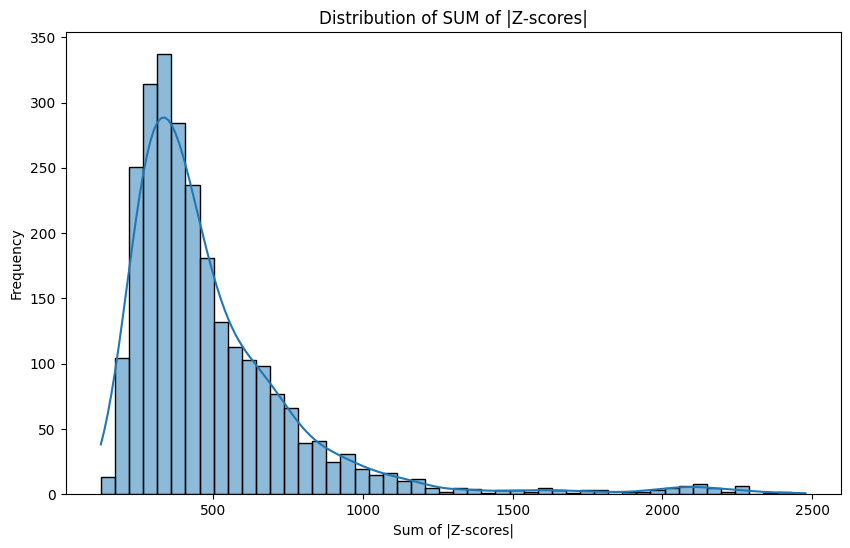

'\nHistogram interpretation : skewed on the right side => most of the samples have relatively lower overall deviation scores\n                               but "a long tail" towards hiwher values that indicates a smaller number of samples with significant deviations \n    \n'

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

threshold = strong_threshold

# By calculating the sum of the absolute Z scores (for each sample) in order to measure its overall deviation.
#    And counting how many features inb each sample have Z-scores beyond threshold.
new_columns = pd.DataFrame({
    'sum_absolute_z': df_normalized[feature_columns].abs().sum(axis=1),                                  # A single metric of how much a feature deviates from the "dmso" control
    'count_deviations': (df_normalized[feature_columns].abs() > threshold).sum(axis=1)                   # How many features deviate significantly in each sample
})
df_normalized = pd.concat([df_normalized, new_columns], axis=1)     
df_normalized = df_normalized.copy()                                                         

df_normalized['sum_absolute_z'] = df_normalized[feature_columns].abs().sum(axis=1)                       # A single metric of how much a feature deviates from the "dmso" control
df_normalized['count_deviations'] = (df_normalized[feature_columns].abs() > threshold).sum(axis=1)       # how many features deviate significantly in each sample
#print(df_normalized)

# Histogram of the sum of absolute Z-scores
plt.figure(figsize=(10, 6))
sns.histplot(df_normalized['sum_absolute_z'], bins=50, kde=True)    # kde : in order to have a smooth approximation of the distribution
plt.title('Distribution of SUM of |Z-scores|')
plt.xlabel('Sum of |Z-scores|')                       # the overall deviation scores of the samples
plt.ylabel('Frequency')                               # the number of samples that fall into each range of deviation scores

plt.savefig(results_dir + 'distribution_abs(z_score)', dpi=150, bbox_inches='tight') 

plt.show()


"""
Histogram interpretation : skewed on the right side => most of the samples have relatively lower overall deviation scores
                               but "a long tail" towards hiwher values that indicates a smaller number of samples with significant deviations 
    
"""

In [24]:
# In order to detect which compounds are causing the most significant overall deviation from the "dmso" I ended up 
#    grouping samples by CPD_NAME to identify which compounds consistently cause deviations in the feature.
#    For each group mean deviation score is calculated.
compound_deviation = df_normalized.groupby('CPD_NAME')['sum_absolute_z'].mean().sort_values(ascending=False)
#print(compound_deviation)

In [25]:
deviation_df = compound_deviation.reset_index()
deviation_df.columns = ['CPD_NAME', 'sum_absolute_z']
print(deviation_df)

     CPD_NAME  sum_absolute_z
0   CBK277946     2010.716309
1   CBK309185     1180.839722
2   CBK278009      963.185120
3   CBK277953      903.522644
4   CBK278090      861.578369
..        ...             ...
63  CBK303906      332.768372
64  CBK007461      331.152588
65  CBK278104      330.249115
66  CBK309443      328.725952
67  CBK301268      320.060669

[68 rows x 2 columns]


## Visualization of dimensionality reduction

In [26]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_dimensionality_reduction(data, img_name, title, method='tsne'):
    features = data[[col for col in data.columns if col.startswith('feature_')]]
    compounds = data['CPD_NAME']
    
    if method.lower() == 'tsne':
        model = TSNE(n_components=2, random_state=42)
        results = model.fit_transform(features)
        columns = ['tSNE-1', 'tSNE-2']
    elif method.lower() == 'umap':
        model = umap.UMAP(n_components=2, random_state=42)
        results = model.fit_transform(features)
        columns = ['UMAP-1', 'UMAP-2']
    else:
        raise ValueError("Method should be either 'tsne' or 'umap'")
    
    result_df = pd.DataFrame(results, columns=columns)
    result_df['Compound'] = compounds.values

    unique_compounds = result_df['Compound'].unique()
    palette = {compound: 'black' if compound == '[dmso]' else sns.color_palette('tab20', len(unique_compounds))[list(unique_compounds).index(compound)]
               for compound in unique_compounds}

    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=result_df, x=columns[0], y=columns[1], hue='Compound', palette=palette, s=70)
    plt.title(title)
    plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)

    plt.savefig(os.path.join(results_dir, img_name), dpi=150, bbox_inches='tight')
    plt.show()
    

2024-10-18 14:23:51.272246: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Top 20 compounds with abs(Z) > 3

In [27]:
top_20_compounds = df_normalized.groupby('CPD_NAME')['sum_absolute_z'].mean().nlargest(20).index
top_20_data = df_normalized[df_normalized['CPD_NAME'].isin(top_20_compounds)]

features = top_20_data[[col for col in df_normalized.columns if col.startswith('feature_')]]
compounds = top_20_data['CPD_NAME']

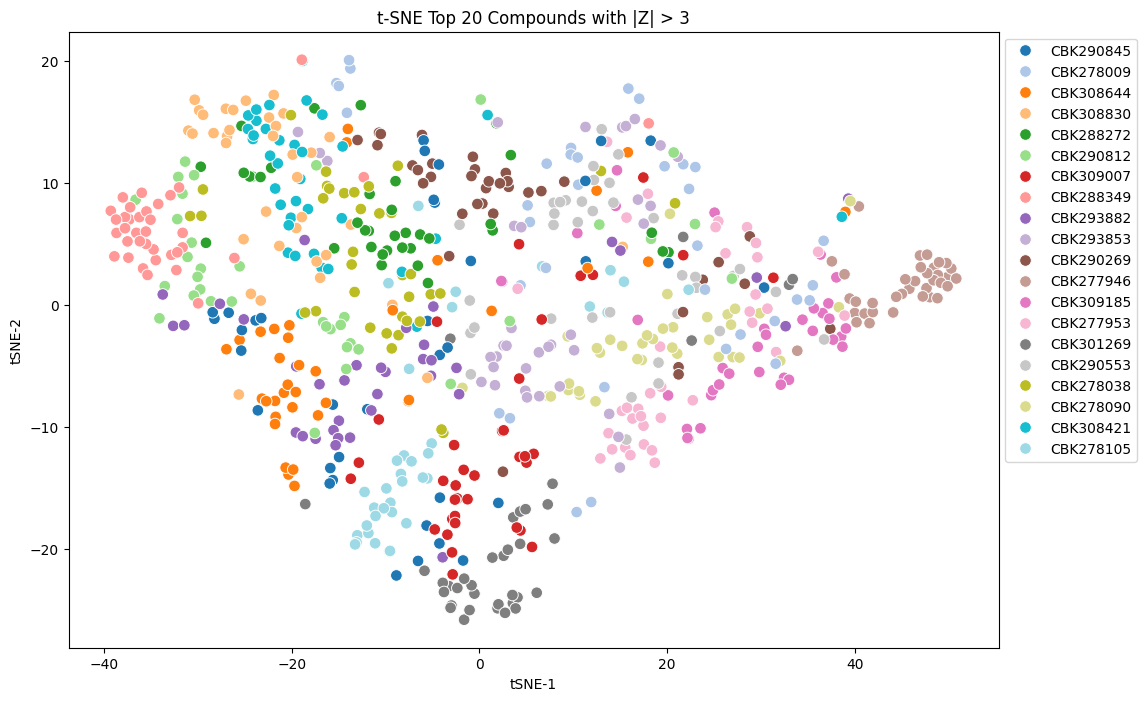

In [50]:
plot_dimensionality_reduction(data=top_20_data, img_name='tSNE_z_score_Top20_strong_devation', title='t-SNE Top 20 Compounds with |Z| > 3', method='tsne')


/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


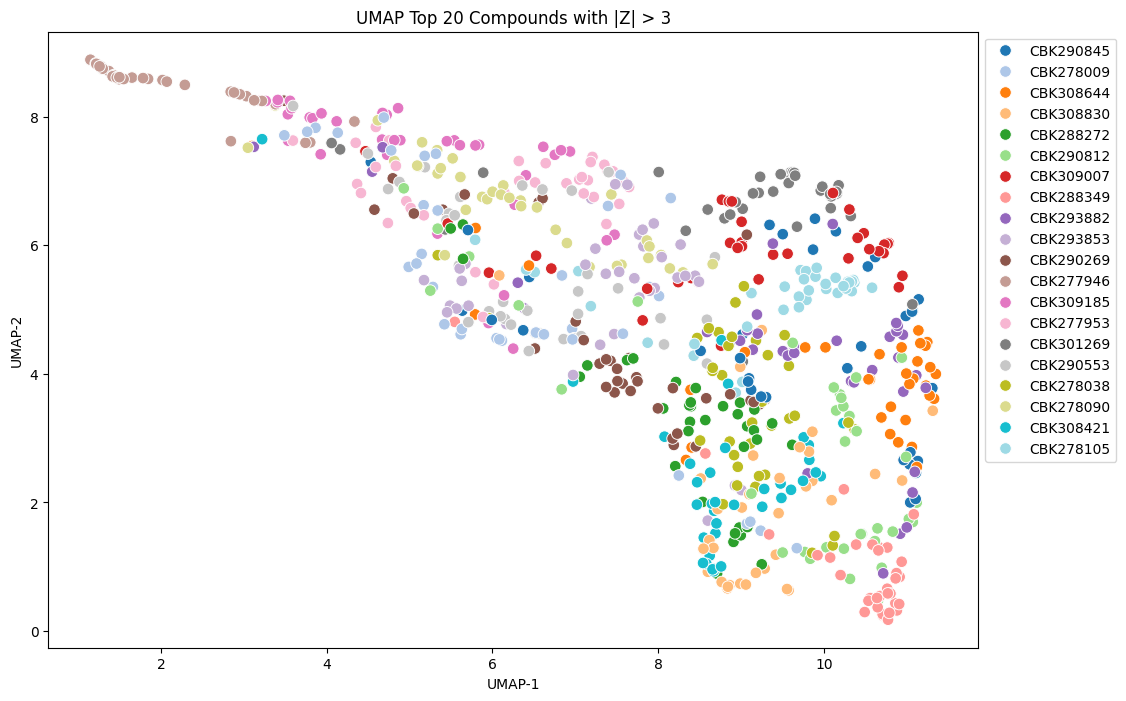

In [51]:
plot_dimensionality_reduction(data=top_20_data, img_name='UMAP_z_score_Top20_strong_devation', title='UMAP Top 20 Compounds with |Z| > 3', method='umap')


## All compounds

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


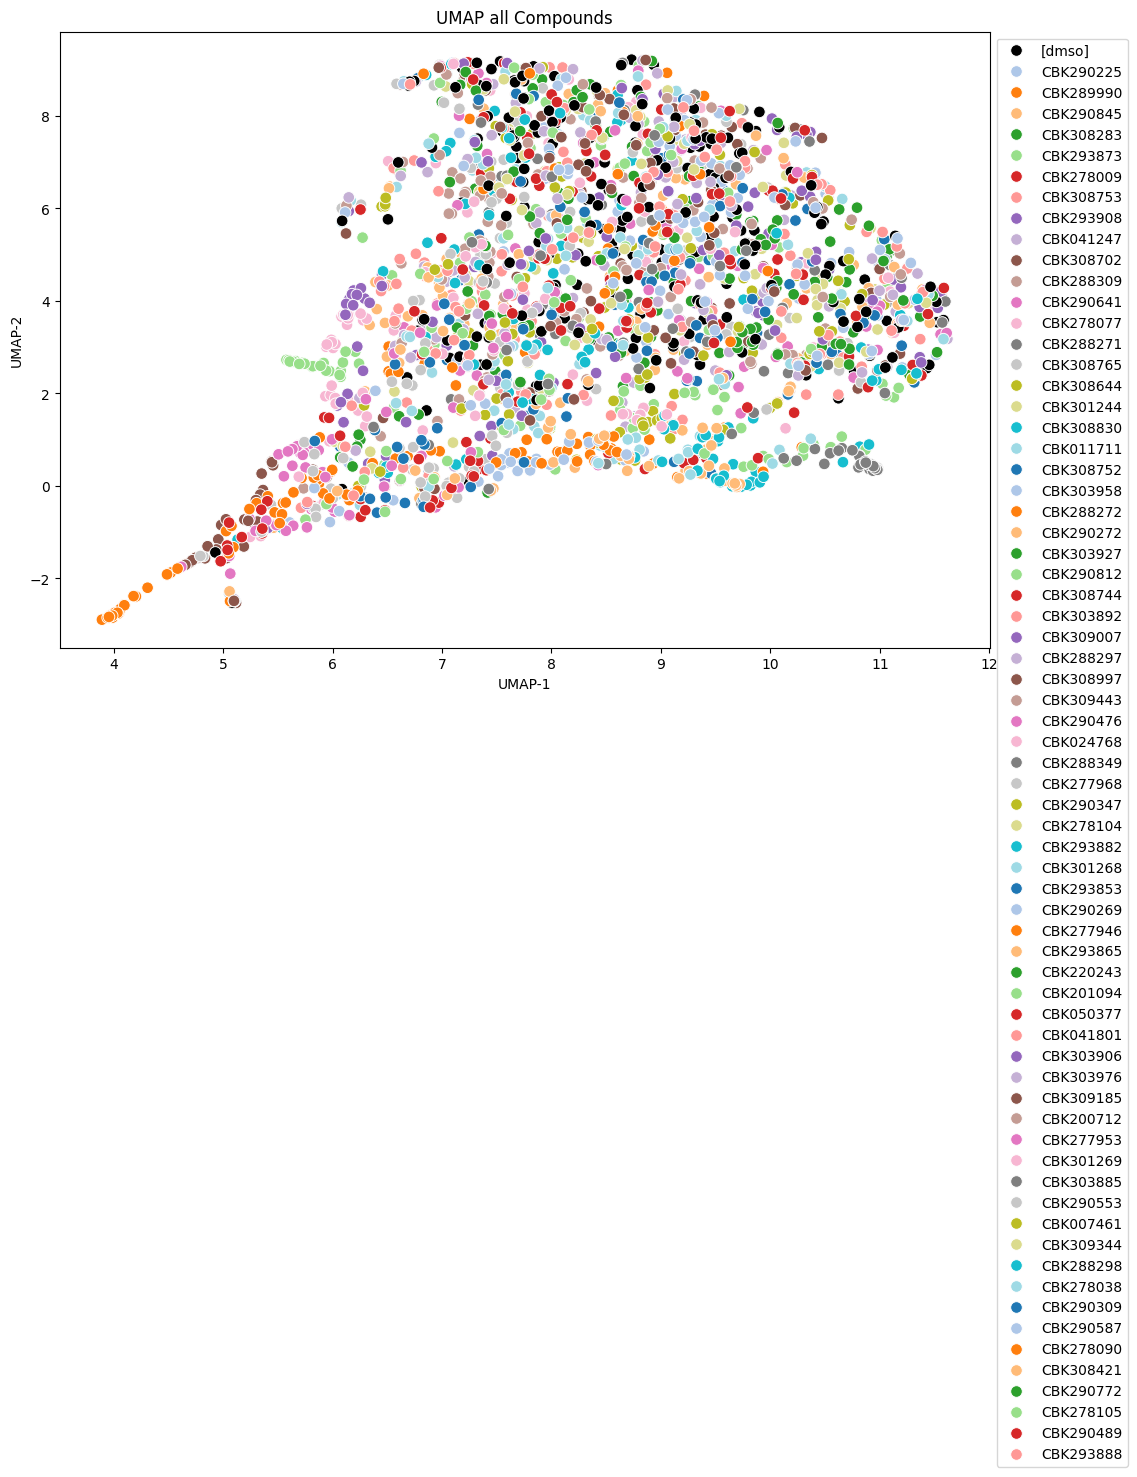

In [30]:
plot_dimensionality_reduction(data=df_normalized, img_name='UMAP_z_score_all_Compounds', title='UMAP all Compounds', method='umap')


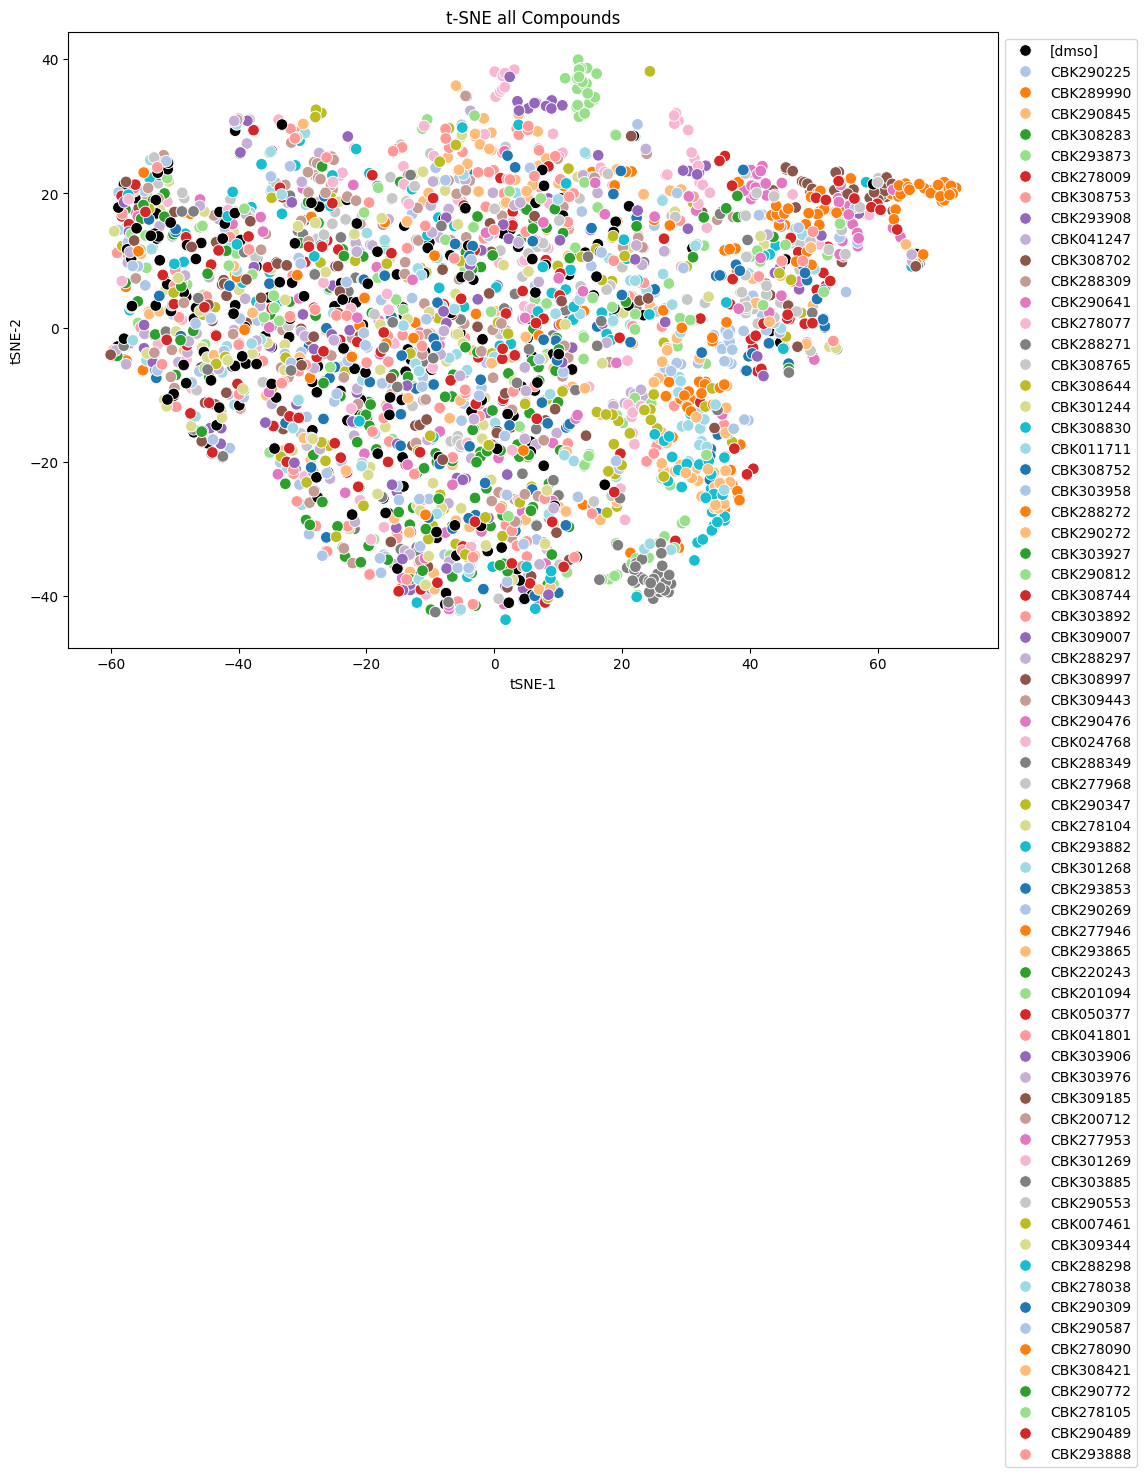

In [31]:
plot_dimensionality_reduction(data=df_normalized, img_name='tSNE_z_score_all_Compounds', title='t-SNE all Compounds', method='tsne')


## Top 19 compounds and DMSO

In [32]:
top_20_compounds = df_normalized.groupby('CPD_NAME')['sum_absolute_z'].mean().nlargest(19).index
top_20_dmso_data = df_normalized[df_normalized['CPD_NAME'].isin(top_20_compounds) | (df_normalized['CPD_NAME'] == '[dmso]')]

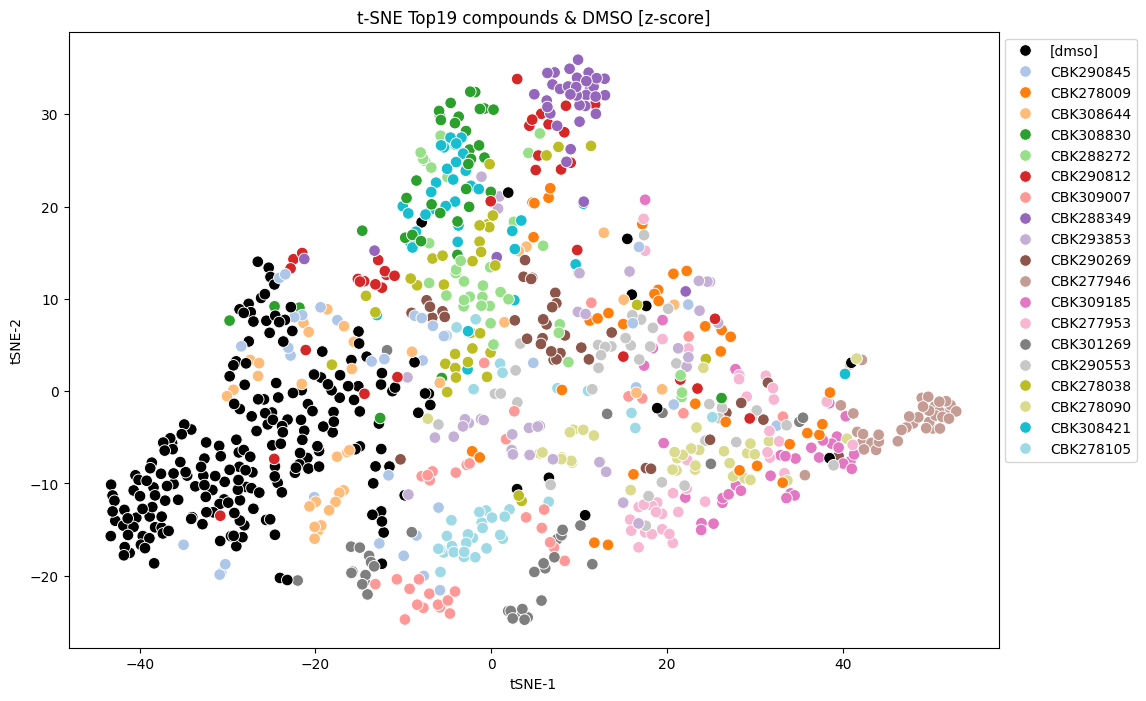

In [33]:
plot_dimensionality_reduction(data=top_20_dmso_data, img_name='tSNE_z_score_Top19_Compounds_DMSO', title='t-SNE Top19 compounds & DMSO [z-score]', method='tsne')


/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


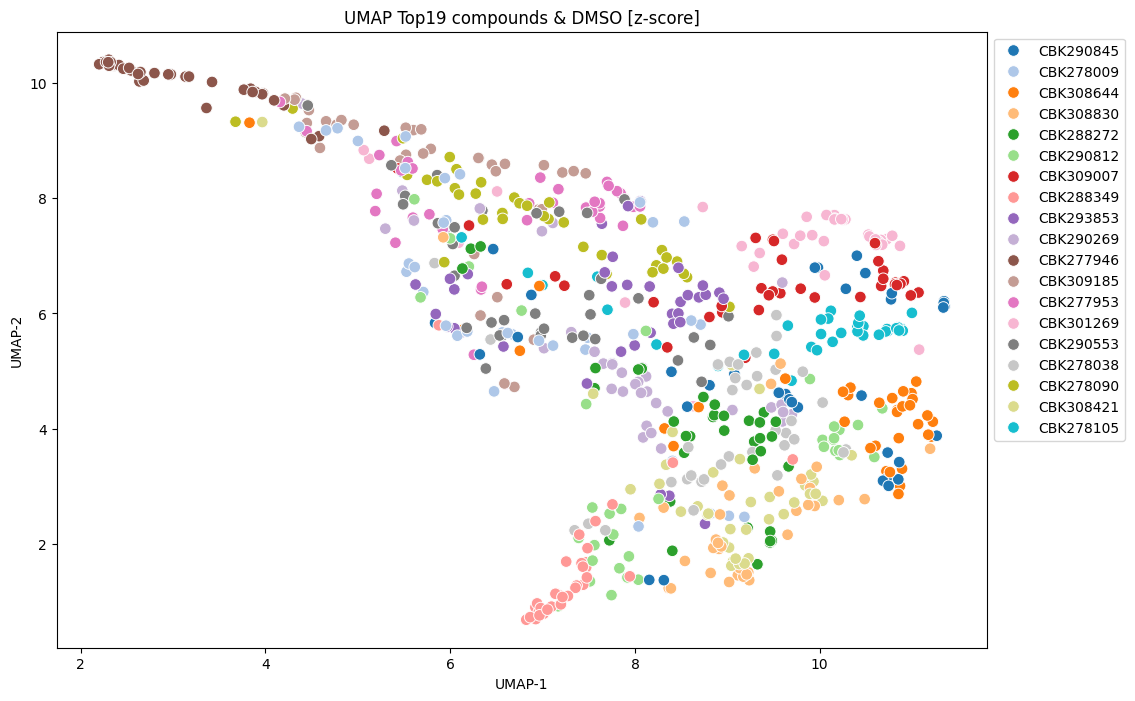

In [52]:
plot_dimensionality_reduction(data=top_20_dmso_data, img_name='UMAP_z_score_Top19_Compounds_DMSO', title='UMAP Top19 compounds & DMSO [z-score]', method='umap')


## Top 20 compounds (not necessery contain DMSO)

In [35]:
top_20_compounds = df_normalized.groupby('CPD_NAME')['sum_absolute_z'].mean().nlargest(19).index
top_20_dmso_data = df_normalized[df_normalized['CPD_NAME'].isin(top_20_compounds)]

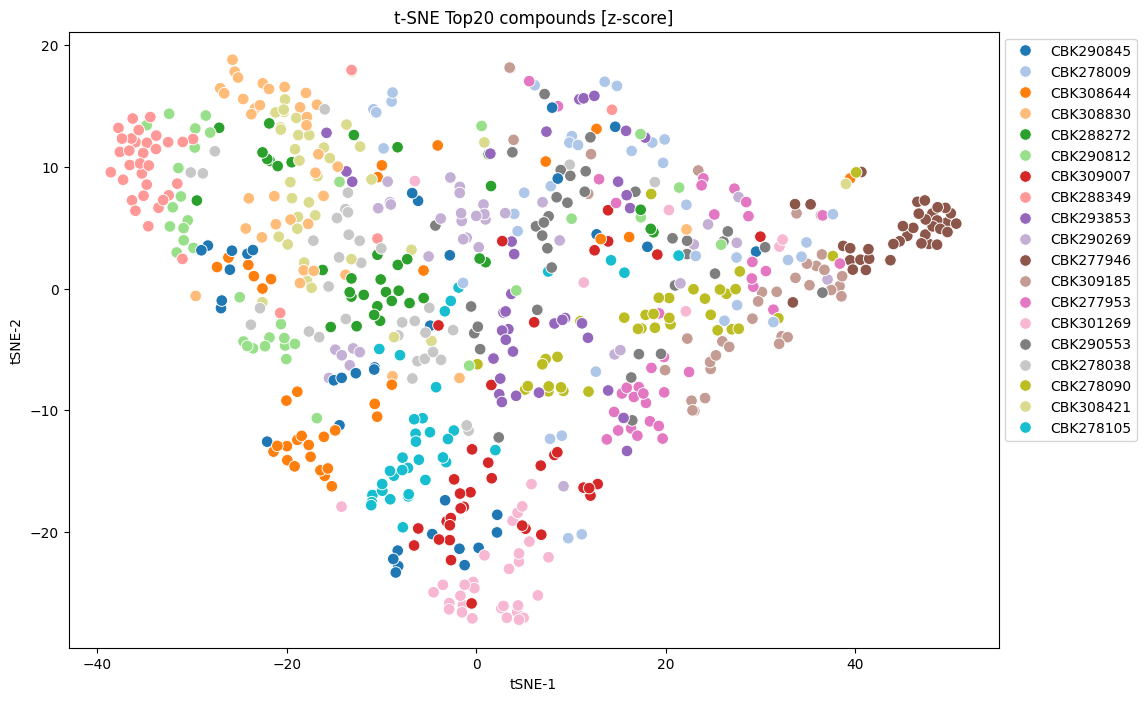

In [36]:
plot_dimensionality_reduction(data=top_20_dmso_data, img_name='tSNE_z_score_Top20_Compounds', title='t-SNE Top20 compounds [z-score]', method='tsne')


/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


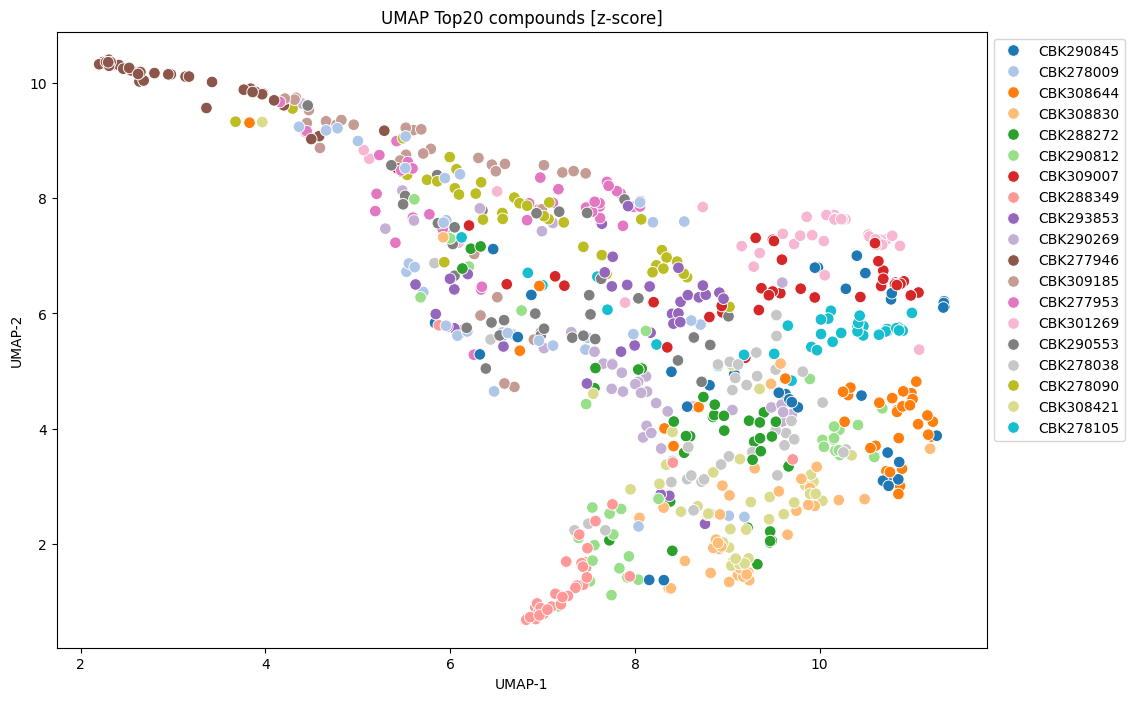

In [37]:
plot_dimensionality_reduction(data=top_20_dmso_data, img_name='UMAP_z_score_Top20_Compounds', title='UMAP Top20 compounds [z-score]', method='umap')


# Grit scores

## Calculating grit scores

In [38]:
from grit import evaluate

def compute_grit(df,feature_columns):
        #df = df.to_pandas()
        #meta = meta.to_pandas()
        df['comp_replicate'] =  df['WELL_POSITION']  + '_' + df['SITE'].astype(str)

        #one_plate = meta.Metadata_Plate.unique()
        grit_scores = evaluate(
            profiles=df,  
            features=feature_columns,
            #meta_features=list(dfZscores.columns[-7:]),# adjust after above
            meta_features=['CPD_NAME','WELL_POSITION','SITE','comp_replicate'],
            replicate_groups={"profile_col": "comp_replicate", "replicate_group_col": "CPD_NAME" },     
                                   # profile_col : id unique replicates, replicate_group_col : indicate grouping
            operation="grit",
            similarity_metric="pearson",
            grit_replicate_summary_method="mean", # median
            grit_control_perts=df.query("CPD_NAME == '[dmso]'").comp_replicate.unique().tolist()
        ).assign(one_plate='P102785')
        return grit_scores
#grit = compute_grit(aggregated_df,feat_col)

In [39]:
#from grit_benchmark import compute_grit

feature_columns = [col for col in df_normalized.columns if col.startswith('feature_')]
metadata_columns = ['CPD_NAME']  

grit_data = df_normalized[metadata_columns + feature_columns]

grit_results = compute_grit(df_normalized, feature_columns=feature_columns)

print(grit_results)

grit_results.to_csv('/share/data/analyses/silvija/RT/data_cloome/our_images/preprocessing_500p/grit_scores_results.csv', index=False)

Generating correlation matrix
Now calculating corelation matrix
(2601, 512)
Now melting datafdrame
Melting to long
Merging meta with correlations
Now starting grit calculation
     perturbation      group          grit one_plate
0           A02_1     [dmso]  1.652425e-17   P102785
1           A02_2     [dmso] -1.652425e-17   P102785
2           A02_3     [dmso]  2.478637e-17   P102785
3           A02_4     [dmso]  3.304850e-17   P102785
4           A02_5     [dmso]  1.652425e-17   P102785
...           ...        ...           ...       ...
2596        P23_5  CBK290225  3.685268e-01   P102785
2597        P23_6  CBK290225  4.713249e-01   P102785
2598        P23_7  CBK290225  4.775859e-01   P102785
2599        P23_8  CBK290225  2.014515e-01   P102785
2600        P23_9  CBK290225  3.276354e-01   P102785

[2601 rows x 4 columns]


In [40]:
grit_grouped = grit_results.groupby('group')['grit'].mean().reset_index()
print(grit_grouped)

        group          grit
0   CBK007461  2.397339e-03
1   CBK011711  5.742603e-03
2   CBK024768  1.255755e-01
3   CBK041247  1.520524e-02
4   CBK041801  1.181623e+00
..        ...           ...
63  CBK309007  1.802230e+00
64  CBK309185  2.465502e+00
65  CBK309344  9.848379e-02
66  CBK309443  7.415218e-02
67     [dmso] -6.466738e-19

[68 rows x 2 columns]


## Distribution of Grit scores

/tmp/ipykernel_4225/1903378395.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grit_grouped, x='group', y='grit', palette='Set3')


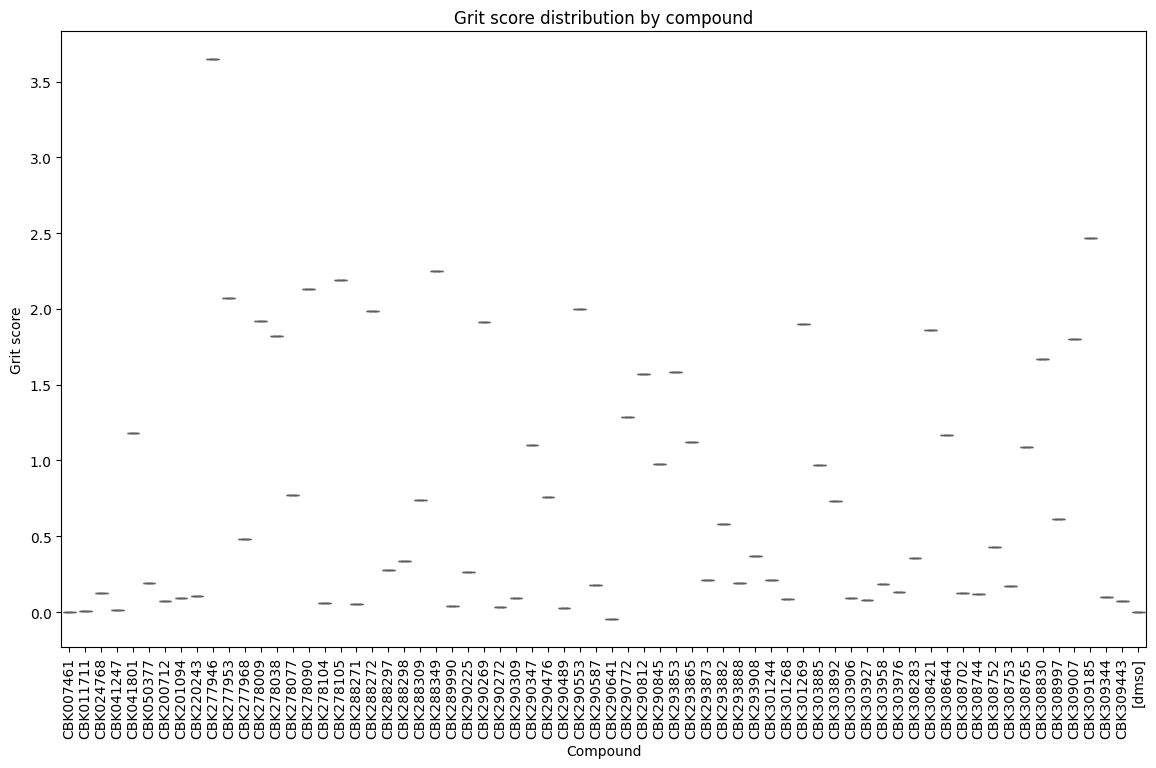

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `grit_results` is a DataFrame with columns 'compound' and 'grit_score'
plt.figure(figsize=(14, 8))
sns.boxplot(data=grit_grouped, x='group', y='grit', palette='Set3')
plt.xticks(rotation=90)
plt.title('Grit score distribution by compound')
plt.xlabel('Compound')
plt.ylabel('Grit score')
plt.savefig(os.path.join(results_dir, "Distribution_grit_score_per_compound"), dpi=150, bbox_inches='tight')
plt.show()


## tSNE visualization of grit scores

In [42]:
top_10_grit = grit_grouped.sort_values(by='grit', ascending=False)['group'].head(10)
top_10_dmso_grit = df_normalized[df_normalized['CPD_NAME'].isin(top_10_grit) | (df_normalized['CPD_NAME'] == '[dmso]')]
#plot_tsne(top_10_dmso_grit, 't-SNE Plot for Top 10 Compounds & DMSO [grit]')

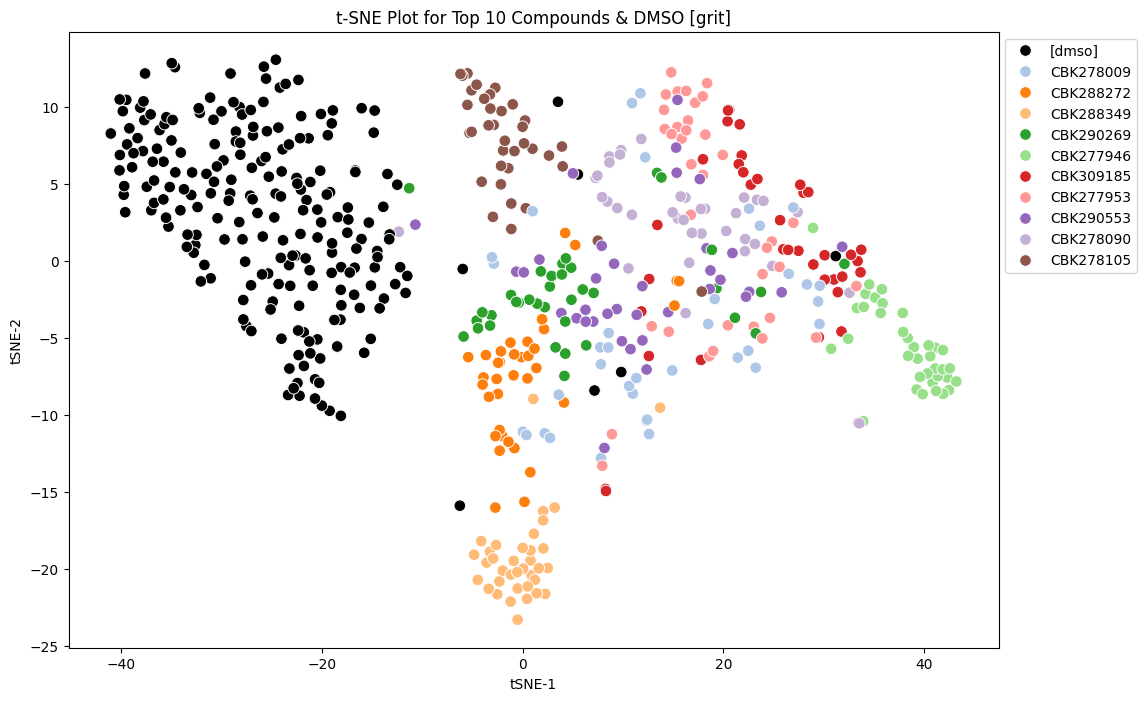

In [43]:
plot_dimensionality_reduction(data=top_10_dmso_grit, img_name='tSNE_grit_Top10_Compounds_DMSO', title='t-SNE Plot for Top 10 Compounds & DMSO [grit]', method='tsne')


/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


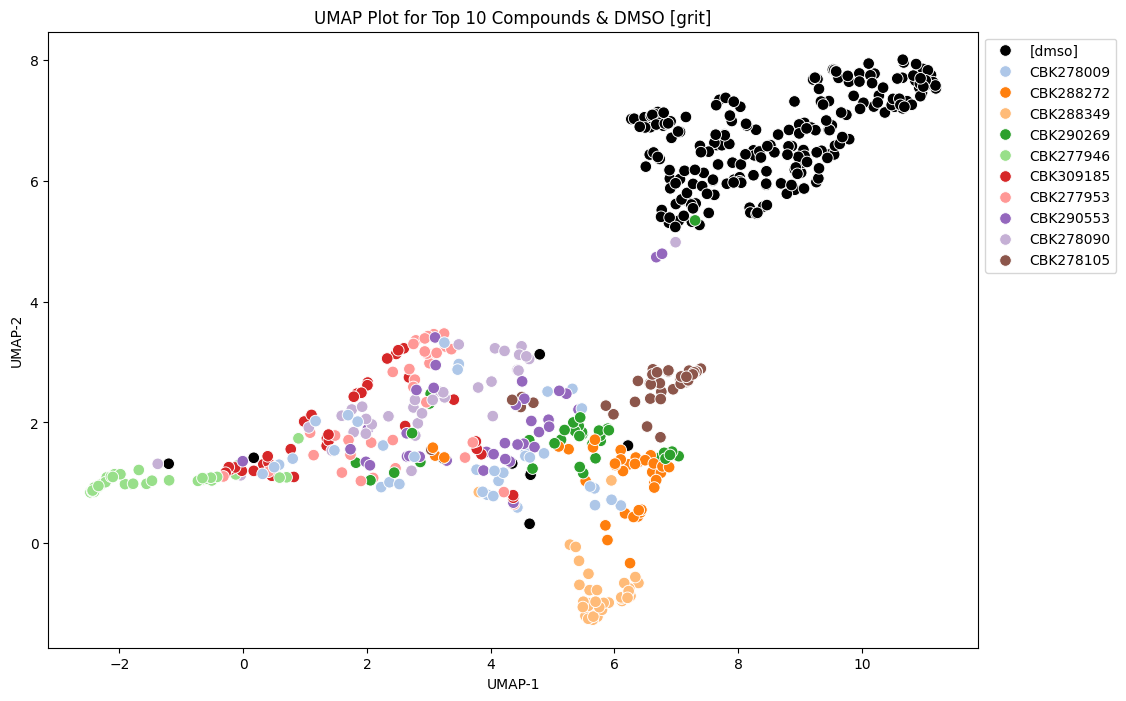

In [44]:
plot_dimensionality_reduction(data=top_10_dmso_grit, img_name='UMAP_grit_Top10_Compounds_DMSO', title='UMAP Plot for Top 10 Compounds & DMSO [grit]', method='umap')


In [45]:
top_10_grit = grit_grouped.sort_values(by='grit', ascending=False)['group'].head(10)
top_10_grit = df_normalized[df_normalized['CPD_NAME'].isin(top_10_grit)]
#plot_tsne(top_10_dmso_grit, 't-SNE Plot for Top 10 Compounds & DMSO [grit]')

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


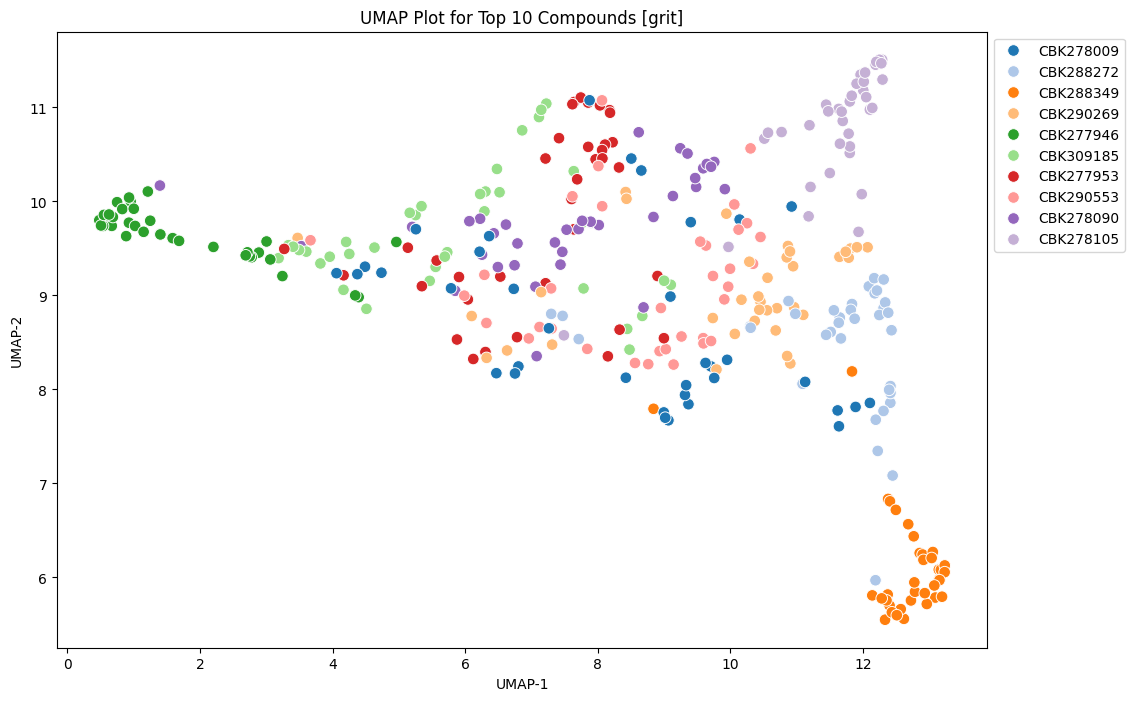

In [55]:
plot_dimensionality_reduction(data=top_10_grit, img_name='UMAP_grit_Top10_Compounds', title='UMAP Plot for Top 10 Compounds [grit]', method='umap')

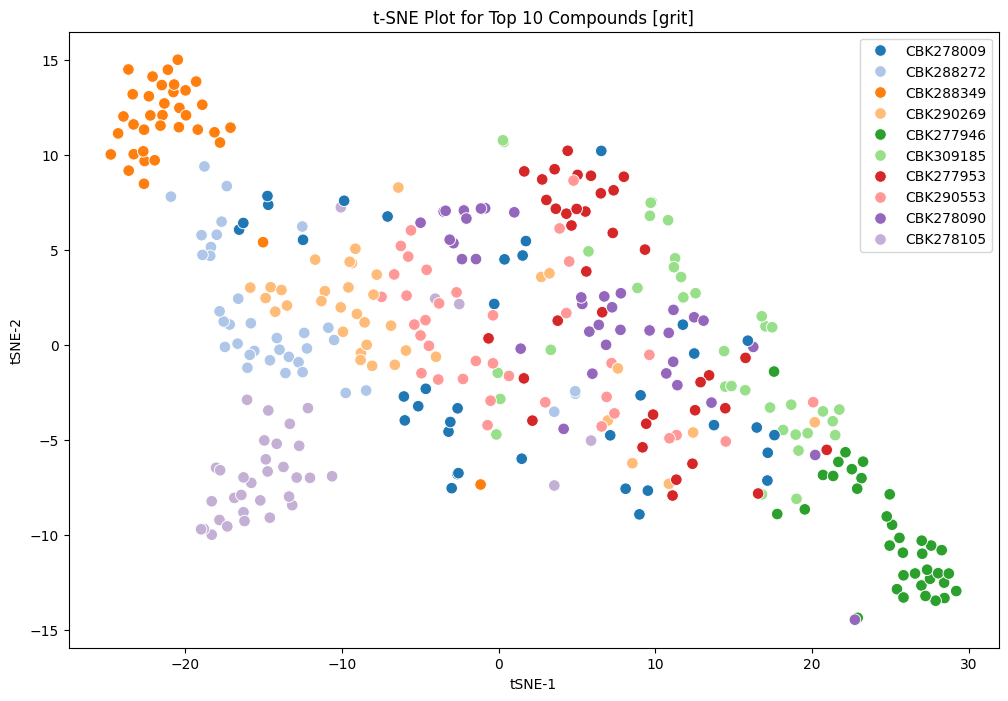

In [56]:
plot_dimensionality_reduction(data=top_10_grit, img_name='tSNE_grit_Top10_Compounds', title='t-SNE Plot for Top 10 Compounds [grit]', method='tsne')

In [47]:
grit = grit_grouped.sort_values(by='grit', ascending=False)['group']
grit = df_normalized[df_normalized['CPD_NAME'].isin(grit)]
#plot_tsne(top_10_dmso_grit, 't-SNE Plot for Top 10 Compounds & DMSO [grit]')

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


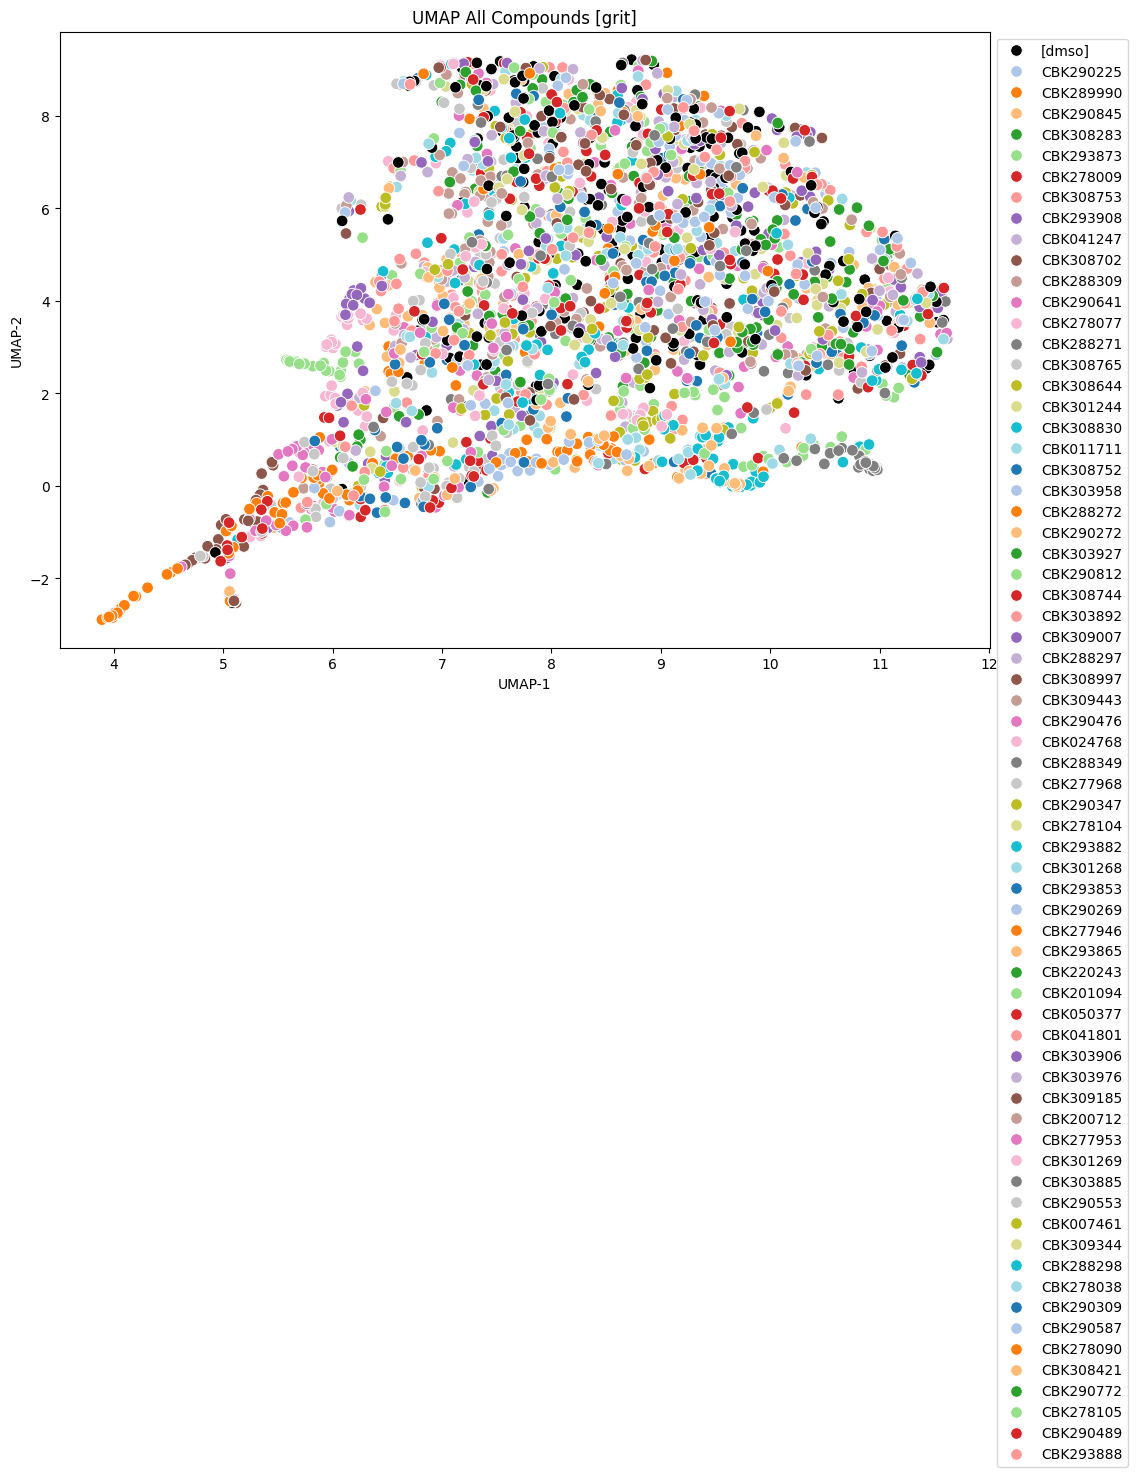

In [53]:
plot_dimensionality_reduction(data=grit, img_name='UMAP_grit_all_compounds', title='UMAP All Compounds [grit]', method='umap')

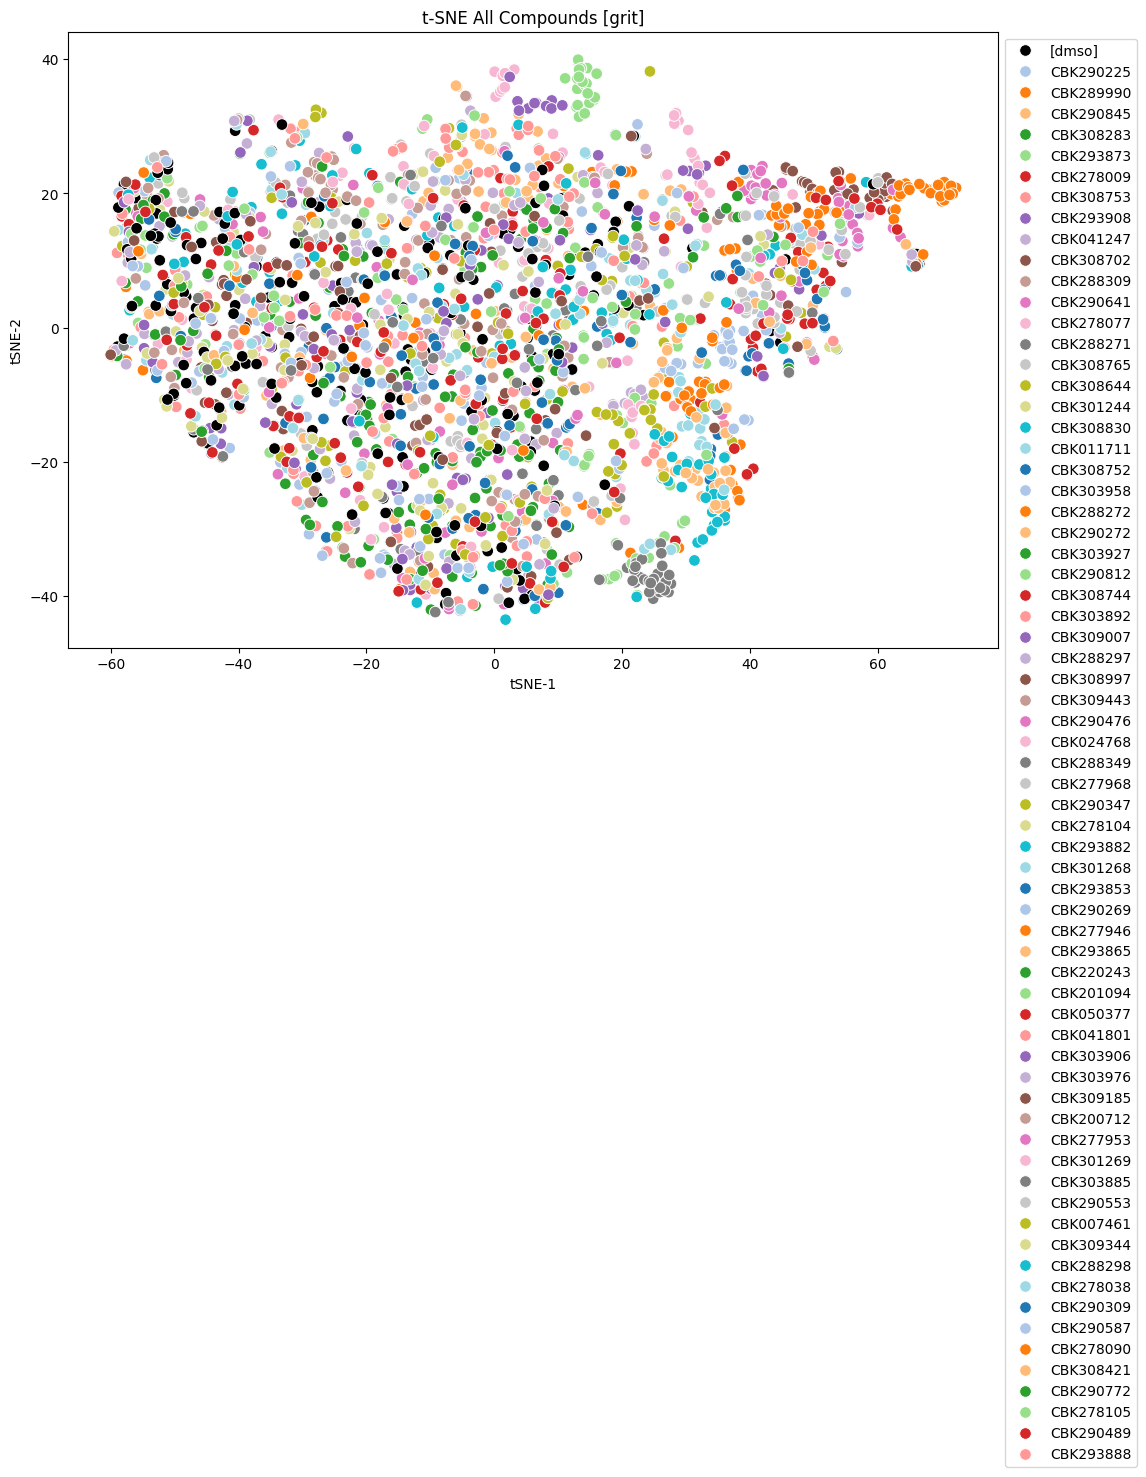

In [54]:
plot_dimensionality_reduction(data=grit, img_name='tSNE_grit_all_compounds', title='t-SNE All Compounds [grit]', method='tsne')

## PCA on grit score data

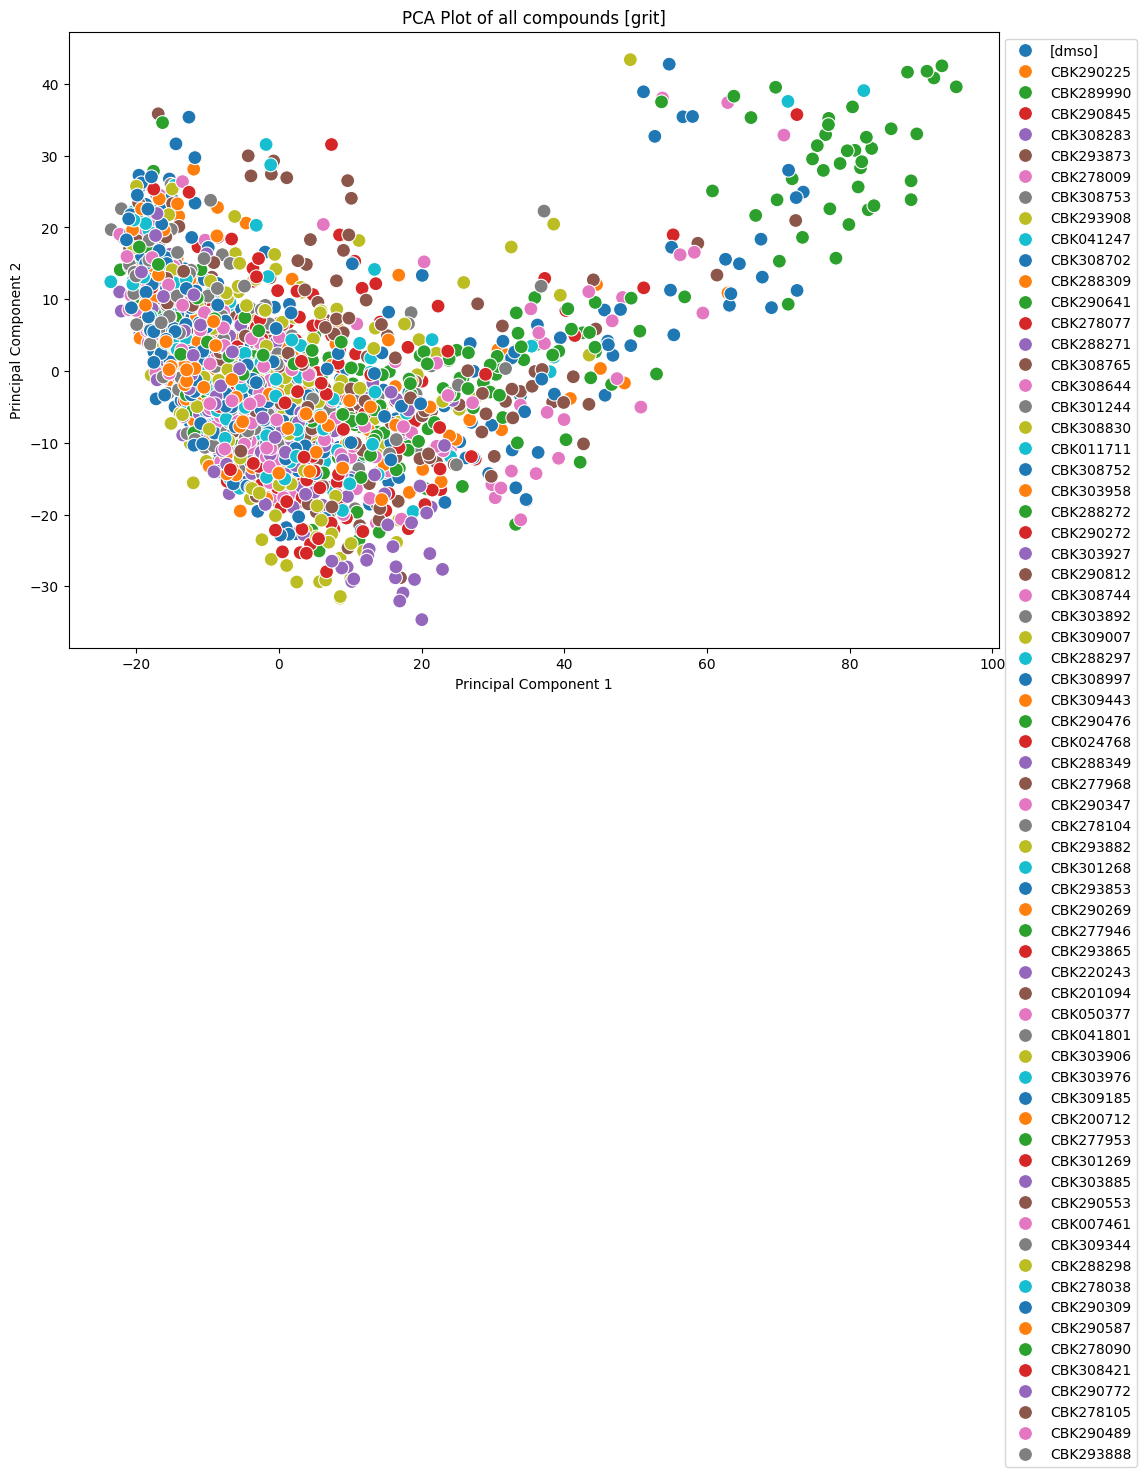

In [57]:
from sklearn.decomposition import PCA

feature_columns = [col for col in df_normalized.columns if col.startswith('feature_')]
features = df_normalized[feature_columns]

pca = PCA(n_components=2)
pca_results = pca.fit_transform(features)

df_normalized['PCA-1'] = pca_results[:, 0]
df_normalized['PCA-2'] = pca_results[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_normalized, x='PCA-1', y='PCA-2', hue='CPD_NAME', palette='tab10', s=100)
plt.title('PCA Plot of all compounds [grit]')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()


## PCA and tSNE on grit score > 1

In [60]:
compounds_high_grit = grit_results[grit_results['grit'] > 1]['group']
filtered_data_high_grit = df_normalized[df_normalized['CPD_NAME'].isin(compounds_high_grit) | (df_normalized['CPD_NAME'] == '[dmso]')].copy()

/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


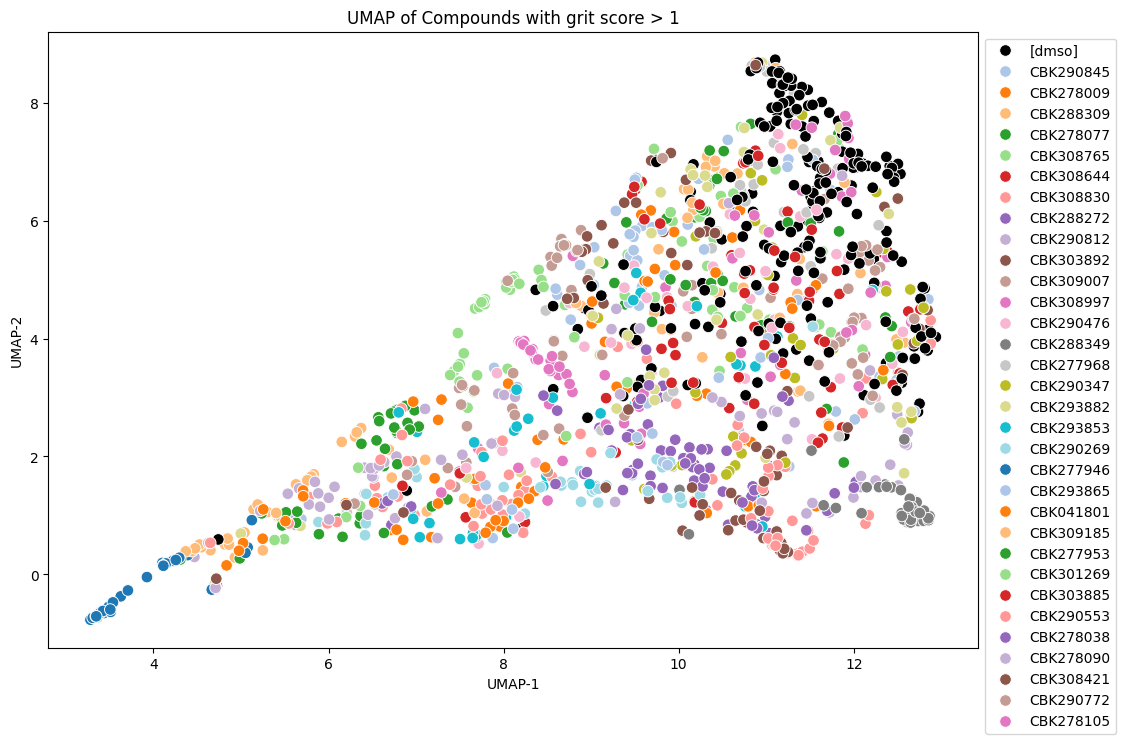

In [61]:
plot_dimensionality_reduction(data=filtered_data_high_grit, img_name='UMAP_grit_Compounds_high_score', title='UMAP of Compounds with grit score > 1', method='umap')

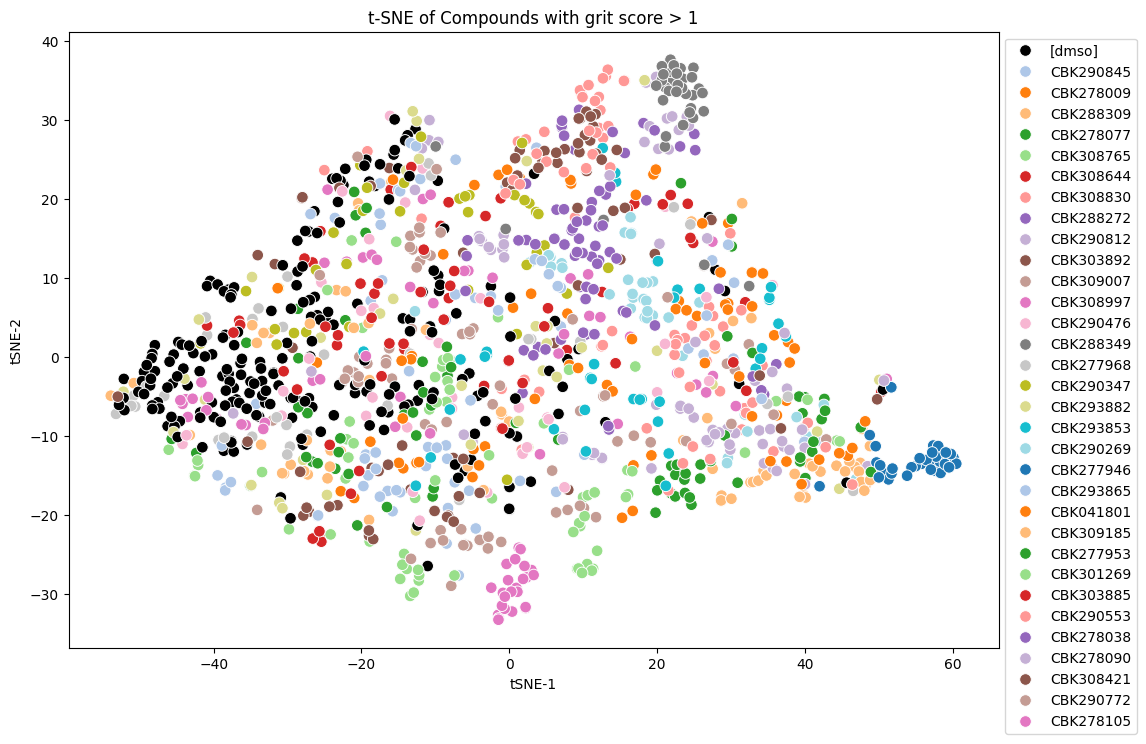

In [62]:
plot_dimensionality_reduction(data=filtered_data_high_grit, img_name='tSNE_grit_Compounds_high_score', title='t-SNE of Compounds with grit score > 1', method='tsne')

In [63]:
len(compounds_high_grit.unique())

32

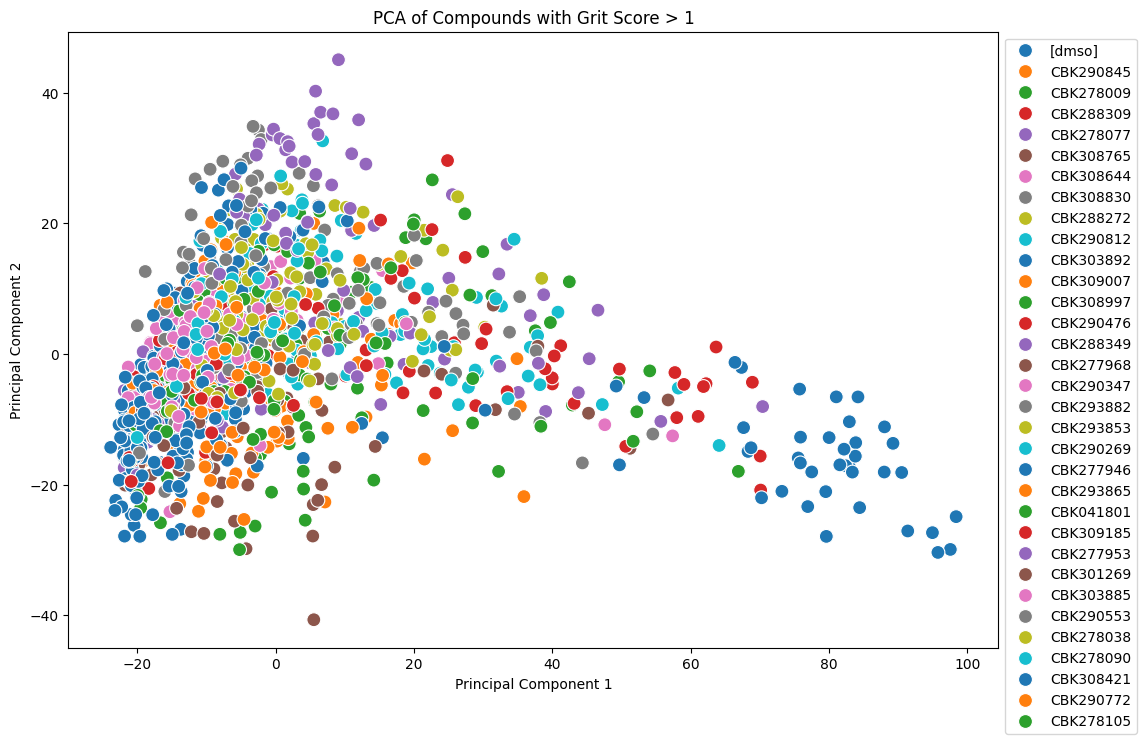

In [64]:
compounds_high_grit = grit_results[grit_results['grit'] > 1]['group']
filtered_data_high_grit = df_normalized[df_normalized['CPD_NAME'].isin(compounds_high_grit) | (df_normalized['CPD_NAME'] == '[dmso]')].copy()
#print(filtered_data_high_grit)

feature_columns = [col for col in filtered_data_high_grit.columns if col.startswith('feature_')]
features_high_grit = filtered_data_high_grit[feature_columns]

pca = PCA(n_components=2)
pca_results_high_grit = pca.fit_transform(features_high_grit)

filtered_data_high_grit.loc[:, 'PCA-1'] = pca_results_high_grit[:, 0]
filtered_data_high_grit.loc[:, 'PCA-2'] = pca_results_high_grit[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_data_high_grit, x='PCA-1', y='PCA-2', hue='CPD_NAME', palette='tab10', s=100)
plt.title('PCA of Compounds with Grit Score > 1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()

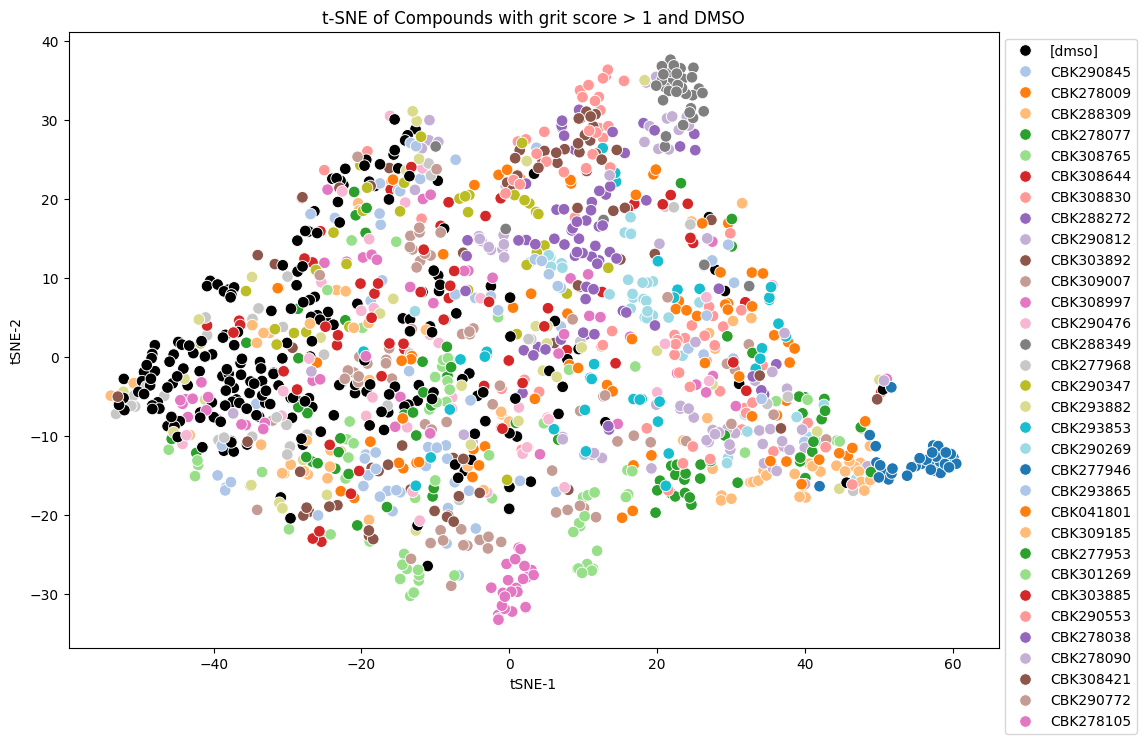

In [65]:
#plot_tsne(filtered_data_high_grit, 't-SNE for grit > 1 & DMSO')
plot_dimensionality_reduction(data=filtered_data_high_grit, img_name='tSNE_grit_Compounds_high_score_DMSO', title='t-SNE of Compounds with grit score > 1 and DMSO', method='tsne')


/usr/local/lib/python3.8/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


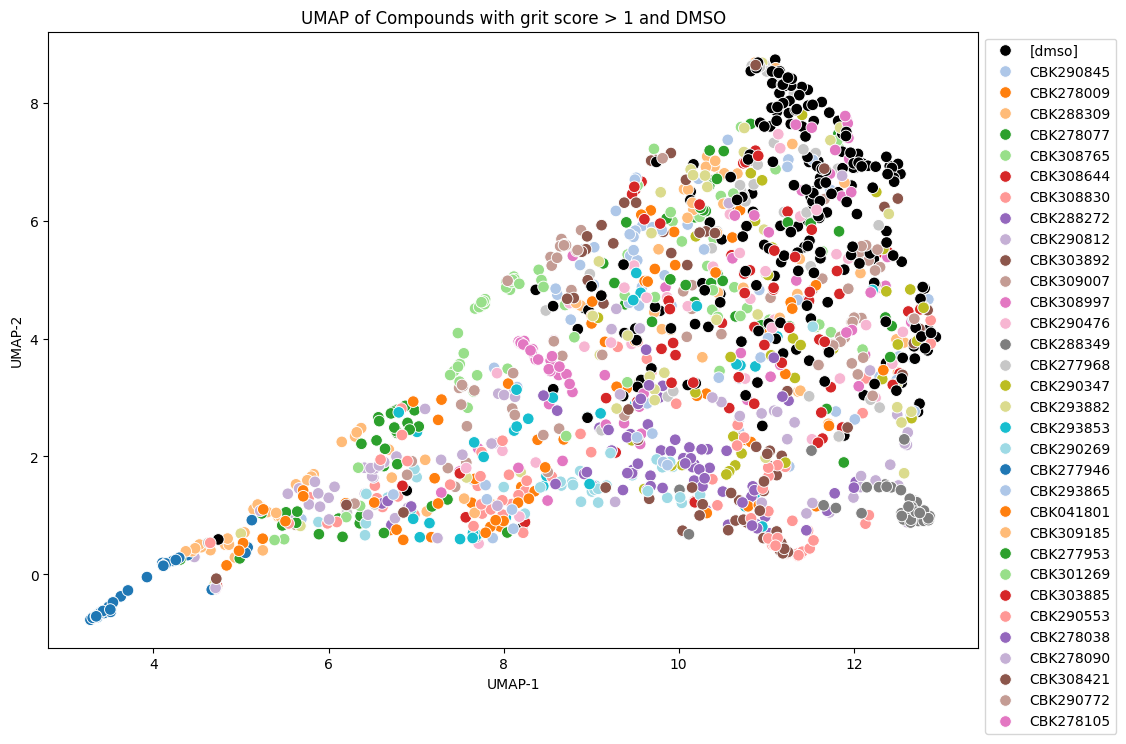

In [66]:
plot_dimensionality_reduction(data=filtered_data_high_grit, img_name='UMAP_grit_Compounds_high_score_DMSO', title='UMAP of Compounds with grit score > 1 and DMSO', method='umap')

## Visualization of grit scores and sum of absolute values for z-score, per compound

In [67]:
#print(deviation_df)
#print(grit_grouped)

scores_df = pd.merge(deviation_df, grit_grouped, left_on='CPD_NAME', right_on='group')
scores_df = scores_df.drop(columns=['group'])

print(scores_df)

     CPD_NAME  sum_absolute_z      grit
0   CBK277946     2010.716309  3.646210
1   CBK309185     1180.839722  2.465502
2   CBK278009      963.185120  1.920376
3   CBK277953      903.522644  2.071194
4   CBK278090      861.578369  2.131029
..        ...             ...       ...
63  CBK303906      332.768372  0.092525
64  CBK007461      331.152588  0.002397
65  CBK278104      330.249115  0.063037
66  CBK309443      328.725952  0.074152
67  CBK301268      320.060669  0.085224

[68 rows x 3 columns]


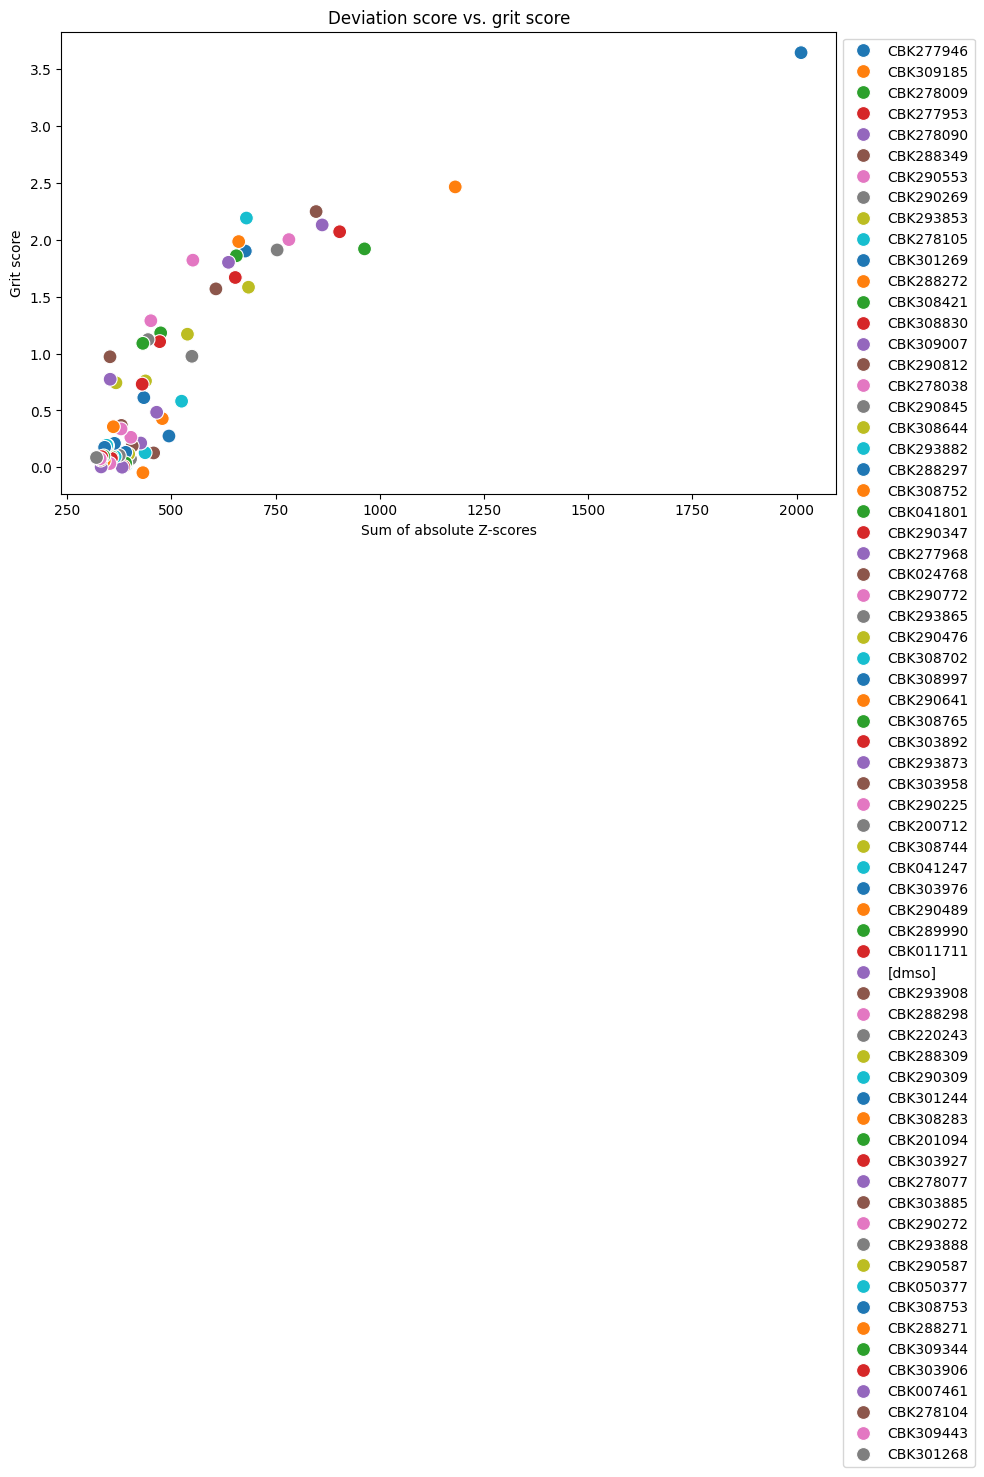

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scores_df, x='sum_absolute_z', y='grit', hue='CPD_NAME', palette='tab10', s=100)
plt.title('Deviation score vs. grit score')
plt.xlabel('Sum of absolute Z-scores')
plt.ylabel('Grit score')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()


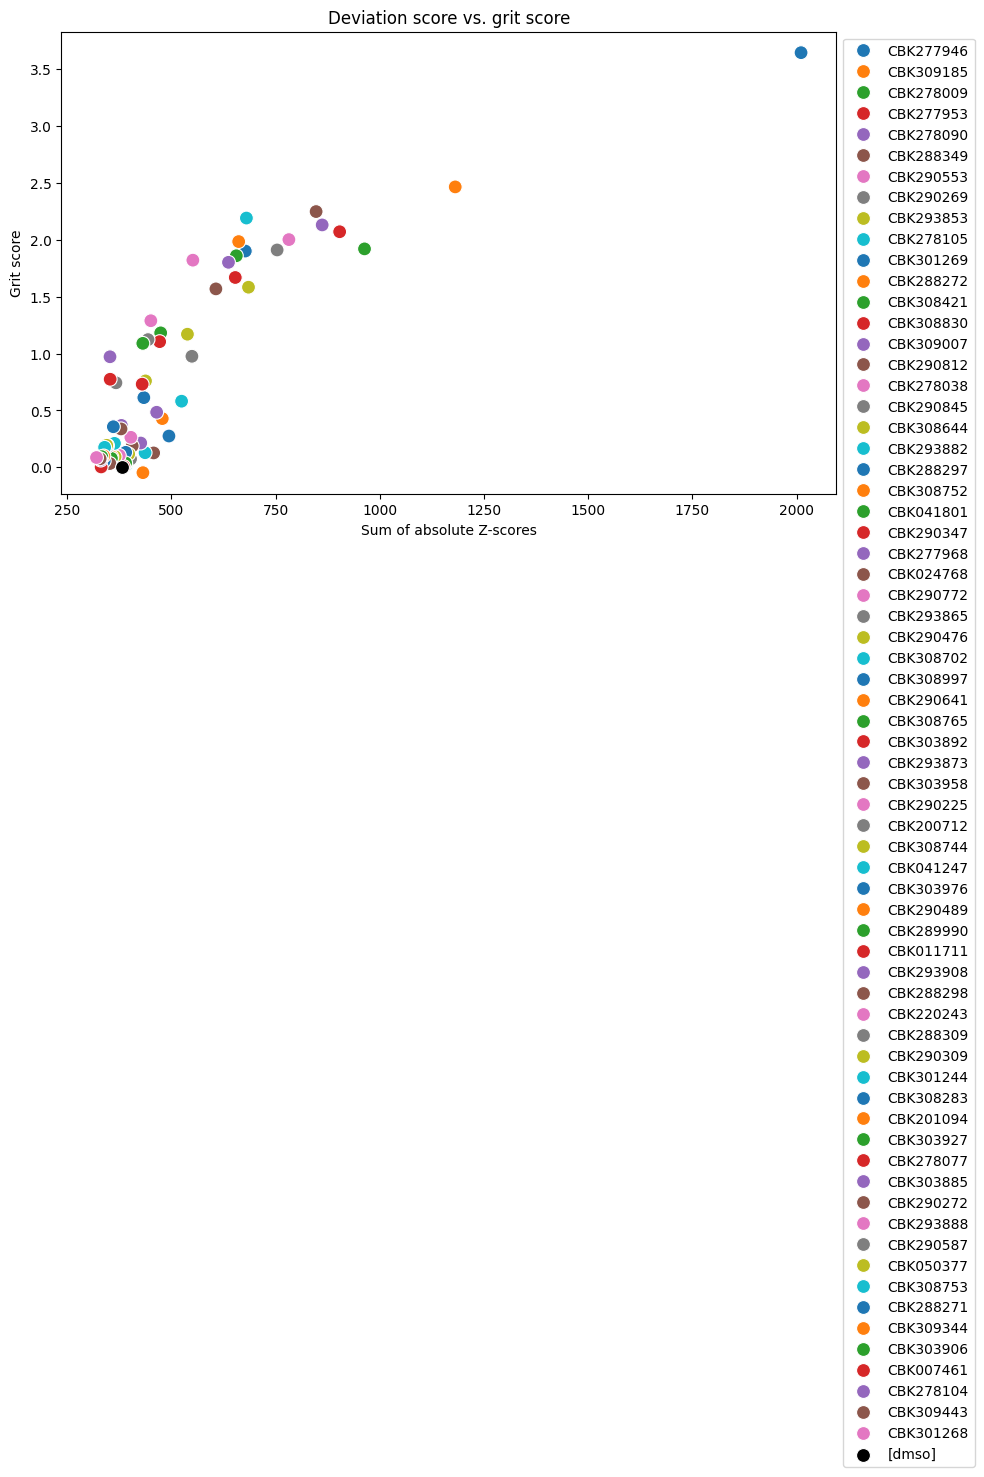

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scores_df[scores_df['CPD_NAME'] != '[dmso]'], 
                x='sum_absolute_z', 
                y='grit', 
                hue='CPD_NAME', 
                palette='tab10', 
                s=100)

sns.scatterplot(data=scores_df[scores_df['CPD_NAME'] == '[dmso]'], 
                x='sum_absolute_z', 
                y='grit', 
                color='black', 
                label='[dmso]', 
                s=100)

plt.title('Deviation score vs. grit score')
plt.xlabel('Sum of absolute Z-scores')
plt.ylabel('Grit score')
plt.savefig(os.path.join(results_dir, "deviation_score_VS_grit_score"), dpi=150, bbox_inches='tight')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()

# zeroshot_phenotype.ipynb : part 2

In [ ]:
val_img_features, val_text_features, val_ids = main(val, checkpoint_path, model, img_path, mol_path, image_resolution)
class_img_features, class_text_features, class_ids = main(classes, checkpoint_path, model, img_path, mol_path, image_resolution)
val_img_features = val_img_features.cpu()
class_img_features = class_img_features.cpu()

In [ ]:
val_img_features.shape

In [ ]:
classes_df = pd.read_csv(classes)
classes_df.set_index("SAMPLE_KEY", inplace=True)
class_inchis = classes_df.loc[class_ids]["INCHIKEY"]

In [ ]:
val_df = pd.read_csv(val)
val_df.set_index("SAMPLE_KEY", inplace=True)

In [ ]:
val_df

In [ ]:
val_inchis = val_df.loc[val_ids]["INCHIKEY"]

In [ ]:
class_dict = {}

for i, inchi in enumerate(class_inchis): 
    class_dict[inchi] = i

In [ ]:
ground_truth = np.zeros(len(val_inchis), dtype=int)

for i, inchi in enumerate(val_inchis): 
    label = class_dict[inchi]
    ground_truth[i] = int(label)

In [ ]:
# Calculating accuracies in several ways

# WAY 1
logits = val_img_features @ class_img_features.T
acc = accuracy_score(ground_truth, logits.argmax(axis=1)) * 100.0
print(acc)

In [ ]:
# WAY 2
N = ground_truth.shape[0]
(np.array(ground_truth) == logits.argmax(axis=1).numpy()).sum() / N * 100

In [ ]:
# WAY 3
ranking = torch.argsort(logits, descending=True)
t = torch.tensor(ground_truth, dtype=torch.int16).view(-1,1)

preds = torch.where(ranking == t)[1]
preds = preds.detach().cpu().numpy()

metrics = {}
for k in [1, 5, 10]:
    metrics[f"R@{k}"] = np.mean(preds < k) * 100
    
print(metrics)

In [ ]:
# WAY 4
probs = (val_img_features @ class_img_features.T).softmax(dim=-1)

metrics_skl = {}
for k in [1, 5, 10]:
    metrics_skl[f"R@{k}"] = top_k_accuracy_score(ground_truth, probs, k=k) * 100
    
print(metrics_skl)

In [ ]:
from scipy.stats import binomtest

n_samples = val_img_features.shape[0]

mdict, cis = {}, {}

for metric, value in metrics.items():
    successes = int(value * n_samples / 100)
    btest = binomtest(k=successes, n=n_samples)
    mdict[metric] = btest.proportion_estimate * 100
    cis[metric] = btest.proportion_ci(confidence_level=0.95)
    
print(mdict)
print(cis)